<img src="https://github.com/isblab/af_pipeline/blob/main/docs/assets/af_pipeline_logo.png?raw=true">

---

[AF-Pipeline](https://isblab.github.io/af_pipeline/
) is a package for the analysis of predictions obtained from AlphaFold2, ColabFold, and AlphaFold3. It involves the following steps:

* Creating input files for prediction (for AlphaFold server or AlphaFold or Colabfold)
* Ranking the predictions based on confidence metrics
* Extracting confidently predicted regions from the predictions (based on pae_to_domains package by Tristan Croll)
* Extracting interacting regions from the predictions

# **Set up AF-Pipeline**
---
(~3 minutes)

In [ ]:
#@title Install konda
import shutil

if shutil.which("konda") is None:
    !pip install konda

    import konda
    konda.install()

    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

Installing Miniconda to /usr/local...
✅ Miniconda installed successfully!
Run '!conda --version' to check if conda is working.

📋 Usage examples:
  konda create -n my_env python=3.11 -y
  konda activate my_env
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [ ]:
#@title Create konda environment "afp"
%%capture
import os
import json

def get_active_env():
    state_file = "/usr/local/konda_state.json"
    if os.path.exists(state_file):
        try:
            with open(state_file, 'r') as f:
                state = json.load(f)
                return state.get("active_env", "base")
        except (json.JSONDecodeError, IOError):
            return "base"
    return "base"

active_env = get_active_env()

# !konda remove -n afp --all

if active_env != "afp":
    !konda create -n afp python=3.12 -y
    !konda activate afp

In [ ]:
#@title Install required Python packages
!konda run "pip install DockQ"
!konda run "pip install numpy==1.26.4 scipy pandas python-igraph ruamel.yaml PyYAML plotly matplotlib openpyxl py3Dmol gdown"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 82.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 23.8 MB/s  0:00:00
  Created wheel for DockQ: filename=dockq-2.1.3-cp312-cp312-linux_x86_64.whl size=261451 sha256=97cee774621ab06cd429937475064856f2622b139fb6e425af0104197ed6c2c5
  Stored in directory: /root/.cache/pip/wheels/df/f6/ca/d656cf4da833de78078f50659f430cca12de0d8fc3bfe2ee36
Successfully built DockQ
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [DockQ]
INFO: pip is looking at multiple versions of scipy to determine which version is compatible

In [ ]:
import sys
sys.path.extend(["/usr/local/envs/afp/lib/python3.12/site-packages", "/usr/local/envs/afp/lib/python3.12"])

In [ ]:
#@title Clone AF-Pipeline repository
import os

if os.path.exists("/content/af_pipeline_tutorial/af_pipeline"):
    !rm -rf /content/af_pipeline_tutorial/af_pipeline/*
    !rm -r /content/af_pipeline_tutorial/af_pipeline

!mkdir -p /content/af_pipeline_tutorial
os.chdir("/content/af_pipeline_tutorial")

!git clone --recursive https://github.com/isblab/af_pipeline.git
os.environ["PYTHONPATH"] += ":/content/af_pipeline_tutorial/af_pipeline:"
!echo $PYTHONPATH
sys.path.append("/content/af_pipeline_tutorial/af_pipeline")

Cloning into 'af_pipeline'...
remote: Enumerating objects: 2467, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 2467 (delta 39), reused 54 (delta 22), pack-reused 2340 (from 2)
Receiving objects: 100% (2467/2467), 151.01 MiB | 16.17 MiB/s, done.
Resolving deltas: 100% (1339/1339), done.
Submodule 'af_pipeline/pae_to_domains' (https://github.com/isblab/pae_to_domains.git) registered for path 'af_pipeline/pae_to_domains'
Cloning into '/content/af_pipeline_tutorial/af_pipeline/af_pipeline/pae_to_domains'...
remote: Enumerating objects: 51, done.        
remote: Counting objects: 100% (51/51), done.        
remote: Compressing objects: 100% (29/29), done.        
remote: Total 51 (delta 23), reused 49 (delta 21), pack-reused 0 (from 0)        
Receiving objects: 100% (51/51), 216.71 KiB | 4.17 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Submodule path 'af_pipeline/pae_to_domains': checked out '281b6803c0d75a0847

### Supporting constants and functions

In [ ]:
#@title Imports - set 1
import io
import os
import sys
import json
import gdown
import time
import subprocess
import random
import warnings
import requests
import requests.adapters
import py3Dmol
import matplotlib
import matplotlib.colors as mcolors
import ipywidgets as widgets
from itertools import zip_longest
from IPython.display import display, HTML
from Bio import PDB
from PIL import Image
from pprint import pprint
from argparse import ArgumentParser
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from enum import StrEnum, auto
from dataclasses import dataclass
from string import Template, ascii_uppercase, ascii_lowercase
from google.colab import files
from pathlib import Path

In [ ]:
#@title Imports - set 2
from af_pipeline.af_input.alphafold3 import AlphaFoldServer
from af_pipeline.utils.file_utils import (
    read_fasta, read_yaml, read_json, write_json
)
from af_pipeline.constants import af_constants
from af_pipeline.rank_predictions.rank_af import (
    get_job_set_dirs, RankAF3JobSet, RankAF2JobSet
)
from af_pipeline.constants.af_constants import (
    ConfigYaml,
    BestPredictionFields,
    MetricLevel,
    PlotType,
    BestPredictionFields,
    MetricLevel,
    FileFormat,
    RES_SEPARATOR,
    RES_SPLITTER,
    SEED_MULTIPLIER,
    RANDOM_SEED,
    MaskedInteractionType,
    MiscStrEnum,
    ReturnType,
    ColorMapScheme,
    BinaryColorMap,
)
from af_pipeline.interaction.interaction import Interaction
from af_pipeline.parser.initialize import Initialize
from af_pipeline.rigid_bodies.rigid_bodies import RigidBodies

In [ ]:
#@title Constants

uniprot_rest_api_sequence = Template("https://rest.uniprot.org//uniprotkb/accessions?accessions=${ids}&format=fasta")

pymol_color_list = [
    "#33ff33","#7fff7f","#00ffff","#ff33cc","#ffff00","#ff9999","#e5e5e5","#7f7fff",
    "#ff7f00","#199999","#ff007f","#ffdd5e","#8c3f99","#b2b2b2","#007fff","#c4b200",
    "#8cb266","#00bfbf","#b27f7f","#fcd1a5","#ff7f7f","#ffbfdd","#7fffff","#ffff7f",
    "#00ff7f","#337fcc","#d8337f","#bfff3f","#ff7fff","#d8d8ff","#3fffbf","#b78c4c",
    "#339933","#66b2b2","#ba8c84","#84bf00","#b24c66","#7f7f7f","#3f3fa5","#a5512b"
]

pymol_cmap = matplotlib.colors.ListedColormap(pymol_color_list)
alphabet_list = list(ascii_uppercase+ascii_lowercase)

aatypes = set('ACDEFGHIKLMNPQRSTVWY')

hover_func = """
function(atom, viewer) {
    if (!atom.label) {
        // atom.b extracts the B-factor value for that specific atom/residue
        var labelText = atom.resn + atom.resi + " (B: " + atom.b.toFixed(1) + ")";
        atom.label = viewer.addLabel(labelText, {
            position: atom,
            backgroundColor: 'black',
            fontColor: 'white',
            backgroundOpacity: 0.8
        });
    }
}
"""

unhover_func = """
function(atom, viewer) {
    if (atom.label) {
        viewer.removeLabel(atom.label);
        delete atom.label;
    }
}
"""

pre_predicted_results = {
    "nap1_homodimer": 'https://drive.google.com/file/d/17kHGsA4fHXY0jVdzOcq28k9tQoiZqiwz/view?usp=drive_link',
    "hifa_complex": 'https://drive.google.com/file/d/13FWDfOKceFca1XV9mZXRaBzLRahX61Xf/view?usp=drive_link',
    "nucleosome": 'https://drive.google.com/file/d/1tD_LIwlAdWgSvokFnGeKHR2tWhULilew/view?usp=drive_link',
    "cadherin_catenin_complex": 'https://drive.google.com/file/d/1ynyNdCtRfra4MbyWmRAUHi9a1MW45dWE/view?usp=drive_link',
    "esterase_homodimer": 'https://drive.google.com/file/d/12NEPaHkL9sErkto-zmXfHQohF7piUNys/view?usp=drive_link',
}

ground_truths = {
    "nap1_homodimer": {"url": 'https://drive.google.com/file/d/1uycBoLj0uDuNdoHG0JAXJJ9uNCSHCqNf/view?usp=drive_link', "pdb_id": "7UN3", "chain_mapping": "AB:BC"},
    "hifa_complex": {"url": 'https://drive.google.com/file/d/1-SqGPDKRHRt0AzqA-sqWxm0h41oklXsQ/view?usp=drive_link', "pdb_id": "1LQB", "chain_mapping": "ABCD:ABCD"},
    "nucleosome": {"url": 'https://drive.google.com/file/d/17rw_G-iBx02eEh4lTAHsiC8PsnBROq86/view?usp=drive_link', "pdb_id": "1AOI", "chain_mapping": "ABCDEFGH:CGDHEAFB"},
    "cadherin_catenin_complex": {"url": 'https://drive.google.com/file/d/1aVM-1gY2tSjWBW3W_erG1dqcL4gDgySV/view?usp=drive_link', "pdb_id": "1I7X", "chain_mapping": "AB:BA"},
    "esterase_homodimer": {"url": 'https://drive.google.com/file/d/1a9_-OlaIauclchXVYWU51Mwp6sGL9MvE/view?usp=drive_link', "pdb_id": "7B5V", "chain_mapping": "AB:AB"},
}

In [ ]:
#@title Utility functions

def install_usalign():
    USALIGN_LINK = "https://aideepmed.com/US-align/bin/module/USalignLinux64.zip"
    SOFTWARE_INSTALL_PATH = "/content/af_pipeline_tutorial"
    USALIGN_ZIP_PATH = os.path.join(SOFTWARE_INSTALL_PATH, "installation_files", "USalignLinux64.zip")
    USALIGN_PATH = os.path.join(SOFTWARE_INSTALL_PATH, "USalign")

    if not os.path.exists(USALIGN_PATH):
        os.makedirs(os.path.dirname(USALIGN_ZIP_PATH), exist_ok=True)

        result = subprocess.run(
        ["curl", "-L", USALIGN_LINK, "-o", USALIGN_ZIP_PATH],
        check=False,
        text=True,
        capture_output=True
    )

        if result.returncode == 0:
            result = subprocess.run(
            ["unzip", USALIGN_ZIP_PATH, "-d", SOFTWARE_INSTALL_PATH],
            check=False,
            text=True,
            capture_output=True
        )

            if result.returncode == 0:
                print(f"Successfully installed USALIGN at {USALIGN_PATH}.")

            else:
                print(f"Error unzipping USALIGN: {result.stderr.replace('\n', ' ')}")

        else:
            print(f"Error downloading USALIGN: {result.stderr.replace('\n', ' ')}")

    else:
        print(f"USALIGN already exists at {USALIGN_PATH}. Skipping installation.")

    USALIGN_BIN = os.path.join(USALIGN_PATH, "USalign")
    print("USALIGN is set up.")

install_usalign()

# Visualization related --------------------------------------------------------

def plot_plddt_legend(dpi=100):

    thresh = [
        'plDDT:',
        'Very low (<50)',
        'Low (50-70)',
        'High (70-90)',
        'Very high (>90)'
    ]
    plt.figure(figsize=(0.5,0.1), dpi=dpi)
    for c in ["#FFFFFF", "#FF7D45","#FFDB13","#65CBF3","#0053D6"]:
        plt.bar(0, 0, color=c)
    plt.legend(
        thresh,
        frameon=False,
        loc='center',
        ncol=5,
        handletextpad=1,
        columnspacing=1,
        markerscale=0.5
    )
    plt.axis(False)

    return plt

def generate_cmap(n: int, scheme: str | ColorMapScheme = ColorMapScheme.SOFT_WARM) -> list[str]:
    """ Generate a list of n colors based on the specified color scheme.
    (modfied from chatgpt)

    ## Arguments:

    - **n (int)**:<br />
        Number of colors to generate.

    - **scheme (str | ColorMapScheme, optional):**:<br />
        Color scheme to use for generating colors. Choose from the following:
        - `standard`: Standard RGB colors.
        - `non_bright`: Muted colors with reduced brightness.
        - `earth_tone`: Colors inspired by natural earth tones.
        - `cool_tone`: Colors with a cool, calming palette.
        - `soft_warm`: Colors with a soft, warm palette.
        - `contrasting_non_bright`: Alternating between darker and lighter muted tones.
        Defaults to `soft_warm`.

    ## Returns:

    - **list**:<br />
        List of n colors in hexadecimal format.
    """

    import random
    import time

    colors = set()
    start = time.time()

    assert n > 0; "Number of colors must be greater than 0"
    if n != 2:
        assert scheme != ColorMapScheme.BINARY; "Binary scheme is only valid for 2 colors"

    if n == 2 and scheme == ColorMapScheme.BINARY:
        return [BinaryColorMap.ZERO_C, BinaryColorMap.ONE_C]

    while len(colors) < n:
        if scheme == ColorMapScheme.STANDARD:
            r = random.randint(0, 255)
            g = random.randint(0, 255)
            b = random.randint(0, 255)

        elif scheme == ColorMapScheme.NON_BRIGHT:
            r = random.randint(50, 180)
            g = random.randint(50, 180)
            b = random.randint(50, 180)

        elif scheme == ColorMapScheme.EARTH_TONE:
            r = random.randint(100, 180)
            g = random.randint(60, 140)
            b = random.randint(40, 120)

        elif scheme == ColorMapScheme.COOL_TONE:
            r = random.randint(50, 120)
            g = random.randint(100, 180)
            b = random.randint(120, 255)

        elif scheme == ColorMapScheme.SOFT_WARM:
            r = random.randint(180, 255)
            g = random.randint(130, 200)
            b = random.randint(90, 160)

        elif scheme == ColorMapScheme.CONTRASTING_NON_BRIGHT:
            if len(colors) % 2 == 0:  # Alternate between darker and lighter muted tones
                r = random.randint(40, 120)
                g = random.randint(40, 120)
                b = random.randint(40, 120)
            else:
                r = random.randint(140, 200)
                g = random.randint(140, 200)
                b = random.randint(140, 200)

        else:
            raise ValueError(
                "Invalid scheme. Choose from "\
                f"{list(ColorMapScheme)}"
            )

        color = "#{:02x}{:02x}{:02x}".format(r, g, b)
        colors.add(color)

        if time.time() - start > 10:
            break

    return list(colors)

def get_res_color(bfactor):
    if bfactor < 50:
        return "#FF7D45"
    elif 50 <= bfactor < 70:
        return "#FFDB13"
    elif 70 <= bfactor < 90:
        return "#65CBF3"
    else:
        return "#0053D6"

def show_pdb(
    source_cif_file,
    rigid_body_pdb_file,
    show_sidechains=False,
    show_mainchains=False,
    color="lDDT"
):
    ext = os.path.splitext(rigid_body_pdb_file)[1]
    f_name = os.path.basename(rigid_body_pdb_file)

    with open(rigid_body_pdb_file, "r") as f:
        pdb_data = f.read()

    with open(source_cif_file, "r") as f:
        cif_data = f.read()

    hex_colors = ["#FF7D45", "#FFDB13", "#65CBF3", "#0053D6"]
    cmap = mcolors.LinearSegmentedColormap.from_list("custom", hex_colors)
    norm = mcolors.Normalize(vmin=0, vmax=100)

    view = py3Dmol.view(
        js='https://3dmol.org/build/3Dmol.js',
        viewergrid=(1, 2),
        width=1000,
        linked=True
    )
    view.setBackgroundColor('#FFFFFF')

    view.addModel(cif_data, "cif", viewer=(0, 0))
    view.addModel(pdb_data, "pdb", viewer=(0, 1))
    view.setStyle({}, {"cartoon": {"color": "#CCCCCC"}})

    pdb_parser = PDB.PDBParser(QUIET=True)
    cif_parser = PDB.MMCIFParser(QUIET=True)

    rb_structure = pdb_parser.get_structure("rb", rigid_body_pdb_file)
    pred_structure = cif_parser.get_structure("prediction", source_cif_file)

    rb_model = rb_structure[0]
    pred_model = pred_structure[0]
    num_chains_rb = len(rb_model)
    num_chains_pred = len(pred_model)

    if color == "lDDT":

        for chain in pred_model:
            for residue in chain:
                if "CA" in residue:
                    ca_atom = residue["CA"]
                    ca_bfactor = ca_atom.get_bfactor()

                    if ca_bfactor is not None:
                        hex_color = get_res_color(ca_bfactor)
                        view.addStyle(
                            {"chain": chain.id, "resi": residue.id[1]},
                            {"cartoon": {"color": hex_color}},
                            viewer=(0, 0)
                        )
                elif "C4" in residue:
                    c4_atom = residue["C4"]
                    c4_bfactor = c4_atom.get_bfactor()

                    if c4_bfactor is not None:
                        hex_color = get_res_color(c4_bfactor)
                        view.addStyle(
                            {"chain": chain.id, "resi": residue.id[1]},
                            {"cartoon": {"color": hex_color}},
                            viewer=(0, 0)
                        )
                elif "C2" in residue:
                    c2_atom = residue["C2"]
                    c2_bfactor = c2_atom.get_bfactor()

                    if c2_bfactor is not None:
                        hex_color = get_res_color(c2_bfactor)
                        view.addStyle(
                            {"chain": chain.id, "resi": residue.id[1]},
                            {"cartoon": {"color": hex_color}},
                            viewer=(0, 0)
                        )

        for chain in rb_model:
            for residue in chain:
                if "CA" in residue:
                    ca_atom = residue["CA"]
                    ca_bfactor = ca_atom.get_bfactor()

                    if ca_bfactor is not None:
                        hex_color = get_res_color(ca_bfactor)
                        view.addStyle(
                            {"chain": chain.id, "resi": residue.id[1]},
                            {"cartoon": {"color": hex_color}},
                            viewer=(0, 1)
                        )
                elif "C4" in residue:
                    c4_atom = residue["C4"]
                    c4_bfactor = c4_atom.get_bfactor()

                    if c4_bfactor is not None:
                        hex_color = get_res_color(c4_bfactor)
                        view.addStyle(
                            {"chain": chain.id, "resi": residue.id[1]},
                            {"cartoon": {"color": hex_color}},
                            viewer=(0, 1)
                        )
                elif "C2" in residue:
                    c2_atom = residue["C2"]
                    c2_bfactor = c2_atom.get_bfactor()

                    if c2_bfactor is not None:
                        hex_color = get_res_color(c2_bfactor)
                        view.addStyle(
                            {"chain": chain.id, "resi": residue.id[1]},
                            {"cartoon": {"color": hex_color}},
                            viewer=(0, 1)
                        )

    elif color == "chain":
        chain_colors = generate_cmap(n=num_chains_pred,scheme="standard")
        for n,chain,color in zip(range(num_chains_pred+1),alphabet_list,chain_colors):
            view.setStyle({'chain':chain},{'cartoon': {'color':color}}, viewer=(0, 0))
        for n,chain,color in zip(range(num_chains_rb+1),alphabet_list,chain_colors):
            view.setStyle({'chain':chain},{'cartoon': {'color':color}}, viewer=(0, 1))

    if show_sidechains:
        BB = ['C','O','N']
        view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                            {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
        view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                            {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
        view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                            {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

    if show_mainchains:
        BB = ['C','O','N','CA']
        view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

    # Apply the hover effects to the viewer
    view.setHoverable({}, True, hover_func, unhover_func)
    view.zoomTo()

    return view

def plot_pae(pae, output_dir, lengths_dict, af_offset):
    fig = plt.figure(figsize=(20, 20))
    plt.rcParams['font.size'] = 16
    plt.rcParams['axes.titlesize'] = 28
    plt.rcParams['axes.labelsize'] = 22
    plt.rcParams['xtick.labelsize'] = 13
    plt.rcParams['ytick.labelsize'] = 13
    plt.imshow(pae, cmap="Greens_r", vmax=31.75, vmin=0, interpolation="nearest")

    cumu_len = 0
    ticks = []
    ticks_labels = []

    for chain_id, p_length in lengths_dict.items():
        if chain_id == MiscStrEnum.TOTAL:
            continue

        cumu_len += p_length
        if cumu_len != pae.shape[1]:
            plt.axhline(y=cumu_len, color='red', linestyle='--', linewidth=0.75)
            plt.axvline(x=cumu_len, color='red', linestyle='--', linewidth=0.75)

        if af_offset is not None:
            ticks_labels.extend([
                f"\n{af_offset.get(chain_id, [1, 1])[0]}" ,
                f"{af_offset.get(chain_id, [1, 1])[1]}\n"
            ])
        else:
            ticks_labels.extend([
                "\n1",
                f"{lengths_dict[chain_id]}\n"
            ])

        if cumu_len-p_length not in ticks:
            ticks.extend([cumu_len-p_length, cumu_len])
        else:
            ticks.extend([cumu_len-p_length+1, cumu_len])

    plt.xlim(0, pae.shape[0])
    plt.ylim(0, pae.shape[1])
    plt.gca().invert_yaxis()
    plt.yticks(ticks, ticks_labels)
    plt.xticks(ticks, ticks_labels, rotation=90, ha='center')
    plt.title(f"Predicted aligned error (PAE)", pad=20)
    plt.xlabel("Scored residue")
    plt.ylabel("Aligned residue")

    ax = plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=1.2)
    plt.colorbar(label="Predicted Alignment Error (PAE)", orientation="horizontal", cax=cax)
    plt.savefig(os.path.join(output_dir, f"pae.{FileFormat.PNG}"), transparent=True)
    plt.close(fig)

def remove_transparency(img_path):

    img = Image.open(img_path).convert("RGBA")
    white_bg = Image.new("RGBA", img.size, "WHITE")
    alpha_composite = Image.alpha_composite(white_bg, img)
    final_img = alpha_composite.convert("RGB")
    buffer = io.BytesIO()
    final_img.save(buffer, format="PNG")

    return buffer.getvalue()

def initialize_config_widget(config_yaml, config_file):

    display(HTML('''
    <style>
        .mytext textarea {
            font-size: 0.9vw; /* Change to your desired size */
            /* color: blue;     Optional: change text color */
        }
    </style>
    '''))

    config_input = widgets.Textarea(
        value=config_yaml,
        placeholder='Enter text here...',
        description='Config:',
        layout=widgets.Layout(width='100%', height='250px')
    )

    config_input.add_class("mytext")

    # Create a button widget
    button = widgets.Button(
        description='Save',
        button_style='success'
    )

    # Define the button click event
    def show_save_config(b):
        with open(config_file, "w") as f:
            f.write(config_input.value)
        print(f"Saved config file to {config_file}")

    button.on_click(show_save_config)

    # Display the widgets
    display(config_input, button)

# Fetching sequences from UniProt ----------------------------------------------

def request_session(max_retries: int=3) -> requests.sessions.Session:

    req_sess = requests.Session()
    req_sess.mount("https://", requests.adapters.HTTPAdapter(max_retries=max_retries))
    req_sess.trust_env = False  # Disable environment variables for proxies

    return req_sess

def query_uniprot_api_for_sequences(
    uniprot_ids: list,
    max_retries: int = 3
) -> str:

    joined = ",".join(uniprot_ids)
    req_sess = request_session(max_retries=max_retries)
    response = req_sess.get(uniprot_rest_api_sequence.substitute(ids=joined))

    if response.status_code == 200:
        print("Successfully fetched sequences for given uniprot ids")
        return response.text
    else:
        raise Exception("Error while requesting sequences for given uniprot ids")

def only_uniprot_id_as_header(
    fasta_str: str | None = None,
    fasta_file: str | None = None,
) -> str:

    if (
        (fasta_str is None and fasta_file is None) or
        (fasta_str is not None and fasta_file is not None)
    ):
        raise ValueError(
            """
            Only one of the following should be provided:
            - fasta_str (fasta formatted string containing sequences for the given uniprot ids)
            - fasta_file (path to fasta file containing sequences for the given uniprot ids)
            """
        )

    if fasta_file is not None:
        with open(fasta_file, "r") as f:
            fasta_str = f.read()

    sequences_lines = fasta_str.split("\n")
    for i, line in enumerate(sequences_lines):
        if line.startswith(">"):
            sequences_lines[i] = f">{line.split('|')[1]}"

    fasta = "\n".join(sequences_lines)

    return fasta

def fasta_str_to_dict(fasta_str: str) -> dict:

    fasta_str = fasta_str.splitlines()
    fasta_dict = {}
    for i, line in enumerate(fasta_str):
        if line.startswith(">"):
            seq_name = line[1:].strip()
            fasta_dict[seq_name] = ""
        else:
            fasta_dict[seq_name] += line.strip()

    return fasta_dict

def update_fasta_with_new_sequences(
    fasta: str,
    fasta_path: str
):

    if os.path.exists(fasta_path):
        prot_sequences = read_fasta(fasta_path)
        uniprots_to_add = [s[1:] for s in fasta.split("\n") if s.startswith(">")]
        present_uniprots = list(prot_sequences.keys())
        uniprots_to_add = [
            s for s in uniprots_to_add if s not in present_uniprots
        ]
        if len(uniprots_to_add) > 0:
            new_fasta = query_uniprot_api_for_sequences(uniprot_ids=uniprots_to_add)
            new_fasta = only_uniprot_id_as_header(fasta_str=new_fasta)
            with open(fasta_path, "a") as f:
                f.write(new_fasta)
    else:
        with open(fasta_path, "w") as f:
            f.write(fasta)

# Wrapper function for interaction analysis ------------------------------------

def perform_interaction_analysis(
    best_pred_json_file,
    output_dir,
    overwrite,
    interaction_pae_cutoff,
    plddt_cutoff,
    contact_threshold
):
    os.makedirs(output_dir, exist_ok=True)

    best_preds = read_json(file_path=best_pred_json_file)

    contact_map_files = {}

    for pred_, pred_to_analyse in best_preds.items():
        structure_path = pred_to_analyse.get(BestPredictionFields.STRUCTURE_PATH)
        data_path = pred_to_analyse.get(BestPredictionFields.DATA_PATH)
        af_offset = pred_to_analyse.get(BestPredictionFields.AF_OFFSET, {})
        entity_chain_map = pred_to_analyse.get(BestPredictionFields.ENTITY_CHAIN_MAP, {})
        pred_dir_name = os.path.basename(
        os.path.dirname(os.path.dirname(structure_path))
    )
        output_subdir = os.path.join(output_dir, pred_dir_name)

        if os.path.exists(output_subdir) and overwrite is False:
            print(f"Interacting patches for {pred_dir_name} already exist in {output_subdir}. Skipping...")
            continue
        else:
            shutil.rmtree(output_subdir, ignore_errors=True)

        initialize = Initialize(
        data_file_path=data_path,
        structure_file_path=structure_path,
        af_offset=af_offset,
        rep_atom_dict={},
        average_token_pae=False,
        average_token_plddt=False,
        metric_level=MetricLevel.REPRESENTATIVE_TOKEN,
        use_fast_cif_parser=False,
    )

        af_interaction = Interaction(
        contact_threshold=contact_threshold,
        plddt_cutoff=plddt_cutoff,
        pae_cutoff=interaction_pae_cutoff,
        save_plot=False,
        save_table=True,
        setup_instance=initialize,
    )

        regions_of_interest_ = af_interaction.create_regions_of_interest()

        for region_of_interest in regions_of_interest_:
            chain_ids = list(region_of_interest.keys())
            af_interaction.save_ppair_interaction(
            region_of_interest=region_of_interest,
            output_dir=output_subdir,
            save_plot=True,
            plot_type=PlotType.INTERACTIVE,
            p1_name=entity_chain_map.get(chain_ids[0], chain_ids[0]),
            p2_name=entity_chain_map.get(chain_ids[1], chain_ids[1]),
            concat_residues=True,
            contact_probability=True,
        )
            chain1, chain2 = list(region_of_interest.keys())
            p_names = {
            chain1: entity_chain_map.get(chain1, chain1),
            chain2: entity_chain_map.get(chain2, chain2),
        }
            file_name = "_".join([f"{p_names[k]}_{k}:{v[0]}-{v[1]}" for k, v in region_of_interest.items()])
            cmap_path = os.path.join(output_subdir, f"patches_{file_name}.html")
            if os.path.exists(cmap_path):
                cmap_name = f"{entity_chain_map.get(chain1, chain1)}_{chain1} | {entity_chain_map.get(chain2, chain2)}_{chain2}"
                contact_map_files[cmap_name] = cmap_path

    return contact_map_files

# Wrapper function for confident region extraction -----------------------------

def extract_confident_regions(
    best_pred_json_file,
    output_dir,
    pae_cutoff,
    plddt_cutoff,
    resolution,
    pae_power,
    library,
    min_residues,
    min_proteins,
    overwrite
):
    os.makedirs(output_dir, exist_ok=True)

    best_preds = read_json(file_path=best_pred_json_file)

    rigid_body_files = {"txt":{},"pdb":{},"assessment":{},"pae":{}}

    for pred_head, pred_to_analyse in best_preds.items():
        af_offset = pred_to_analyse.get(BestPredictionFields.AF_OFFSET, None)
        structure_path = pred_to_analyse.get(BestPredictionFields.STRUCTURE_PATH, None)
        data_path = pred_to_analyse.get(BestPredictionFields.DATA_PATH, None)
        entity_chain_map = pred_to_analyse.get(BestPredictionFields.ENTITY_CHAIN_MAP, {})
        dir_name = os.path.basename(os.path.dirname(os.path.dirname(structure_path)))

        rb_dir_name = f"{dir_name}_rigid_bodies"
        save_dir = os.path.join(output_dir, rb_dir_name)

        if os.path.exists(save_dir) and overwrite is False:
            print(f"Rigid bodies for {dir_name} already exist in {save_dir}. Skipping...")
            continue
        else:
            shutil.rmtree(save_dir, ignore_errors=True)

        initialize = Initialize(
            data_file_path=data_path,
            structure_file_path=structure_path,
            af_offset=af_offset,
            rep_atom_dict={},
            average_token_pae=False,
            average_token_plddt=False,
            metric_level=MetricLevel.PER_TOKEN,
            use_fast_cif_parser=False,
        )

        rigid_bodies_extractor = RigidBodies(
            library=library,
            pae_cutoff=pae_cutoff,
            pae_power=pae_power,
            resolution=resolution,
            plddt_cutoff=plddt_cutoff,
            setup_instance=initialize,
        )

        domains = rigid_bodies_extractor.extract_rigid_bodies(
            pae_matrix=rigid_bodies_extractor.pae,
            min_res=min_residues,
            min_proteins=min_proteins,
            plddt_filter=True,
        )

        rigid_bodies_extractor.save_rigid_bodies(
            domains=domains,
            output_dir=save_dir,
            rb_out_fmt=FileFormat.TXT,
            save_structure=True,
            rb_struct_fmt=FileFormat.PDB,
            filter_struct_by_plddt=True,
            protein_chain_map=entity_chain_map
        )

        rigid_bodies_extractor.assess_rigid_bodies(
            domains=domains,
            output_dir=save_dir,
            protein_chain_map=entity_chain_map,
            symmetric_pae=True,
            as_average=True,
            show_interface_residues_only=True,
        )

        rigid_bodies_extractor.show_rigid_bodies_on_pae_matrix(
            domains=domains,
            output_dir=save_dir,
        )

        rigid_bodies_extractor.show_rigid_bodies_on_pae_matrix(
            domains=domains,
            output_dir=save_dir,
        )

        plot_pae(
            pae=rigid_bodies_extractor.pae,
            output_dir=save_dir,
            lengths_dict=rigid_bodies_extractor.lengths_dict,
            af_offset=af_offset,
        )

        rb_txts = list(Path(save_dir).glob("**/*.txt"))
        rb_txts = {f"{f_path.parent.name}|{f_path.stem}": f_path for f_path in rb_txts}

        rb_pdbs = list(Path(save_dir).glob("**/*.pdb"))
        rb_pdbs = {f"{f_path.parent.name}|{f_path.stem}": f_path for f_path in rb_pdbs}

        rb_paes = list(Path(save_dir).glob("**/*.png"))
        rb_paes = {f"{f_path.parent.name}|{f_path.stem}": f_path for f_path in rb_paes if f_path.stem.startswith("rigid_body")}

        rb_assessments = list(Path(save_dir).glob("**/*.xlsx"))
        rb_assessments = {f"{f_path.parent.name}|{f_path.stem}": f_path for f_path in rb_assessments}

        rigid_body_files["txt"].update(rb_txts)
        rigid_body_files["pdb"].update(rb_pdbs)
        rigid_body_files["pae"].update(rb_paes)
        rigid_body_files["assessment"].update(rb_assessments)

        print(f"Rigid bodies for {os.path.basename(structure_path)} saved in {output_dir}")

    return rigid_body_files

# Assessment related -----------------------------------------------------------

def get_dockq_score(model_path, rb_path, gt_path, chain_mapping_model, chain_mapping_rb, col_width=100):

    print("*"*2*col_width)
    print("DockQ score comparison")
    print("*"*2*col_width)

    results1 = subprocess.run(["konda", "run", f"DockQ {model_path} {gt_path} --mapping {chain_mapping_model}"], capture_output=True, text=True)
    results2 = subprocess.run(["konda", "run", f"DockQ {rigid_body_pdb_file} {outpath} --mapping {chain_mapping_rb}"], capture_output=True, text=True)

    command1 = f"DockQ {model_path} {gt_path}"
    command2 = f"DockQ {rigid_body_pdb_file} {outpath}"

    print("Running commands:")
    print(f'1. !konda run "{command1}"')
    print(f'2. !konda run "{command2}"')

    lines1 = results1.stdout.splitlines()
    lines2 = results2.stdout.splitlines()

    col_width = 100

    print("\n" + "=" * (col_width * 2 + 5))
    print(f"{'Model vs GT':<{col_width}} | {'Rigid Body vs GT':<{col_width}}")
    print("=" * (col_width * 2 + 5))

    # zip_longest fills the shorter output with an empty string so nothing gets dropped
    for line1, line2 in zip_longest(lines1, lines2, fillvalue=""):
        # Truncate lines if they exceed column width to keep things clean, or just print them
        print(f"{line1[:col_width]:<{col_width}} | {line2[:col_width]:<{col_width}}")

    print("=" * (col_width * 2 + 5) + "\n")

    if results1.returncode != 0 or results2.returncode != 0:
        print("Warning: One or both DockQ commands returned a non-zero exit code.")

def get_tm_score(model_path, rb_path, gt_path, is_multimer, col_width=100):

    print("*"*2*col_width)
    print("TM-score comparison")
    print("*"*2*col_width)

    usalign_cmd = "/content/af_pipeline_tutorial/USalign/USalign"
    if is_multimer:
        usalign_cmd += " -mm 1"

    results1 = subprocess.run(["konda", "run", f"{usalign_cmd} {model_path} {gt_path}"], capture_output=True, text=True)
    results2 = subprocess.run(["konda", "run", f"{usalign_cmd} {rigid_body_pdb_file} {outpath}"], capture_output=True, text=True)

    command1 = f"/content/af_pipeline_tutorial/USalign/USalign {model_path} {gt_path}"
    command2 = f"/content/af_pipeline_tutorial/USalign/USalign {rigid_body_pdb_file} {outpath}"

    print("Running commands:")
    print(f'1. !konda run "{command1}"')
    print(f'2. !konda run "{command2}"')

    lines1 = results1.stdout.splitlines()
    lines2 = results2.stdout.splitlines()

    print("\n" + "=" * (col_width * 2 + 5))
    print(f"{'Model vs GT':<{col_width}} | {'Rigid Body vs GT':<{col_width}}")
    print("=" * (col_width * 2 + 5))

    for line1, line2 in zip_longest(lines1, lines2, fillvalue=""):
        print(f"{line1[:col_width]:<{col_width}} | {line2[:col_width]:<{col_width}}")

    print("=" * (col_width * 2 + 5) + "\n")

    if results1.returncode != 0 or results2.returncode != 0:
        print("Warning: One or both USalign commands returned a non-zero exit code.")

USALIGN is set up.


# **Example 1 - (Demonstration)**
---

In [ ]:
#@title Carbohydrate esterase homodimer

#@markdown [PDB: 7B5V](https://www.rcsb.org/structure/7B5V)
#@markdown - An enzyme in gut Bacteroidete *Dysgonomonas mossii*
#@markdown - It helps break down complex plant sugars in the human and animal digestive tracts
#@markdown - UniProt IDs:
#@markdown   - Esterase: [F8X1N1](https://www.uniprot.org/uniprotkb/F8X1N1/entry)

# @markdown ---
uniprot_ids = "F8X1N1" #@param {type:"string", placeholder:"Enter a comma separated list of UniProt IDs (e.g. O00629)"}

example_dir = "./example1"
prot_sequences_file = os.path.join(example_dir, "sequences", "protein_sequences.fasta")

os.makedirs(os.path.dirname(prot_sequences_file), exist_ok=True)

fasta = query_uniprot_api_for_sequences(uniprot_ids=uniprot_ids.split(","))
fasta = only_uniprot_id_as_header(fasta_str=fasta)
print(fasta)

update_fasta_with_new_sequences(fasta=fasta, fasta_path=prot_sequences_file)
print(f"Updated fasta file: {prot_sequences_file}")

Successfully fetched sequences for given uniprot ids
>F8X1N1
MKKFFFLHLFIWALTVGAISQNYKSVPNGYDIPRTGISHGQIDTVTYYSKTVDTNRKALV
YTPPGYSKNKQYPVLYLLHGIGGDEKEWFSHGQPQVILDNLYADKKIVPMIVVLPNGRAM
KDDRAIGNIMEAPKVEAFATFEKDLLNDLIPFIQKTYPVLKNQENRALAGLSMGGGQSLN
FGLGNLDIFAWVGGFSSAPNTKTPEVLVPNPDDAKKKLKLLWISCGDKDGLLSFSKRTHD
YLAKNQVPHVYQVIPNGYHDFNIWKQNLYMFSQLLFKPVTADLIEQYSYIPEEAEVGISA
STNIPGAQYPQILSGNRVLFRIKAPDAKRVQVDLGKKYDMVREEEGSWAITTDPIVEGFH
YYSILIDGVAVCDPASRTFYGMSRMASGIEIPEEGVDYYNLKNVPHGQIRQIRYFSDVTK
AWRRAFVYTPAGYDANTSQRYPVLYLQHGGGEDETGWPNQGKMDAIIDNLIAEGKAKPMI
VVMDNGYAVDPSASSANSPQGLRGLFQNSALEKVFINEIIPLVDKEFRTIADRDHRAMAG
LSMGGFQAFQIAMTNLDKFAYVGGFSGGGIIEQGGDFSKMYNNVWSDVDTFNKRVKLIYL
SIGTAEPTNMYQTVNNFHKEFEKAGIKHVYYESPGTSHEWLTWRRSLNQFAELLFK

Updated fasta file: ./example1/sequences/protein_sequences.fasta


## 1.a. Creating input for AlphaFold-server

In [ ]:
config_yaml = """
# Fill up the missing fields

protein_uniprot_map:
  Esterase: "F8X1N1"

af_input_jobs:
  - modelSeeds: [10, 87]
    entities:
    - name: "Esterase"
      type: "proteinChain"
      count: 2
"""

config_file = "config.yaml" #@param {type:"string"}
config_file = os.path.join(example_dir, config_file)

initialize_config_widget(config_yaml=config_yaml, config_file=config_file)

Textarea(value='\n# Fill up the missing fields\n\nprotein_uniprot_map:\n  Esterase: "F8X1N1"\n\naf_input_jobs:…

Button(button_style='success', description='Save', style=ButtonStyle())

Saved config file to ./example1/config.yaml


## 1.b. Create a JSON file for AlphaFold-server

In [ ]:
output_dir = "af_server_json" #@param {type:"string"}
output_dir = os.path.join(example_dir, output_dir)

################################################################################

config_dict = read_yaml(config_file)
protein_sequences = read_fasta(prot_sequences_file)

af_input = AlphaFoldServer(
    config_dict=config_dict,
    protein_sequences=protein_sequences,
)

af_input.write_job_files(output_dir=output_dir)

################################################################################

json_files = list(Path(output_dir).glob("**/*.json"))
json_files = {f_path.stem: f_path for f_path in json_files}

if not json_files:
    print(f"No JSON files found in '{output_dir}'.")
else:
    dropdown = widgets.Dropdown(
        options=list(json_files.keys()),
        description='JSON Files:',
        disabled=False,
    )

    button = widgets.Button(
        description='Download File',
        button_style='success',
        tooltip='Click to download the selected JSON file',
        icon='download'
    )

    def on_button_clicked(b):
        selected_file = dropdown.value
        full_path = json_files[selected_file]
        print(f"Downloading: {selected_file}...")
        files.download(full_path)

    button.on_click(on_button_clicked)

    display(widgets.VBox([dropdown, button]))

2 jobs written for Esterase_2_1t656_set_0


## 1.c. Obtain AlphaFold predictions

- Link to AlphaFold-server: https://alphafoldserver.com/

Only run one of the following cells. You can:
- Upload your own predictions **OR**
- Use pre-predicted AlphaFold-server results

In [ ]:
#@title Upload AlphaFold-server results
import shutil
from google.colab import files

overwrite = True #@param {type: "boolean"}

uploaded = files.upload()

prediction_dir = os.path.join(example_dir, "af_predictions")

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

for filename in uploaded.keys():
    os.makedirs(prediction_dir, exist_ok=True)
    source_path = filename
    destination_path = os.path.join(prediction_dir, filename)
    shutil.move(source_path, destination_path)
    print(f"Moved {filename} to {destination_path}")
    if os.path.exists(destination_path) and not os.path.exists(destination_path.replace(".zip", "")):
        !unzip {destination_path} -d {destination_path.replace(".zip", "")}

In [ ]:
#@title Fetch pre-predicted AlphaFold-server results

pred_name = "esterase_homodimer" #@param {type: "string"}
overwrite = True #@param {type: "boolean"}
url = pre_predicted_results[pred_name]
prediction_dir = os.path.join(example_dir, "af_predictions")
outpath = os.path.join(prediction_dir, f"{pred_name}.zip")
destination_path = os.path.join(prediction_dir, pred_name)

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

os.makedirs(prediction_dir, exist_ok=True)
if os.path.exists(outpath):
    if os.path.exists(destination_path) and os.path.isdir(destination_path):
        print(f"Prediction files already exist in {destination_path}. Skipping...")
    else:
        !unzip {outpath} -d {destination_path}
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)
    !unzip {outpath} -d {destination_path}

Downloading...
From (original): https://drive.google.com/uc?id=12NEPaHkL9sErkto-zmXfHQohF7piUNys
From (redirected): https://drive.google.com/uc?id=12NEPaHkL9sErkto-zmXfHQohF7piUNys&confirm=t&uuid=53712520-1785-4bc7-815c-95b5d4b1e3e9
To: /content/af_pipeline_tutorial/example1/af_predictions/esterase_homodimer.zip
100%|██████████| 30.5M/30.5M [00:00<00:00, 200MB/s]


Archive:  ./example1/af_predictions/esterase_homodimer.zip
  inflating: ./example1/af_predictions/esterase_homodimer/terms_of_use.md  
  inflating: ./example1/af_predictions/esterase_homodimer/esterase_2_1t656_10/fold_esterase_2_1t656_10_job_request.json  
  inflating: ./example1/af_predictions/esterase_homodimer/esterase_2_1t656_10/msas/fold_esterase_2_1t656_10_unpaired_msa_chains_a_b.a3m  
  inflating: ./example1/af_predictions/esterase_homodimer/esterase_2_1t656_10/msas/fold_esterase_2_1t656_10_paired_msa_chains_a_b.a3m  
  inflating: ./example1/af_predictions/esterase_homodimer/esterase_2_1t656_10/templates/fold_esterase_2_1t656_10_template_hit_0_chains_a_b.cif  
  inflating: ./example1/af_predictions/esterase_homodimer/esterase_2_1t656_10/templates/fold_esterase_2_1t656_10_template_hit_1_chains_a_b.cif  
  inflating: ./example1/af_predictions/esterase_homodimer/esterase_2_1t656_10/templates/fold_esterase_2_1t656_10_template_hit_2_chains_a_b.cif  
  inflating: ./example1/af_predict

## 1.d. Rank predictions

- The best model is selected based on the following metrics in order of priority:
    1. Ranking Score
    2. Model Index (lower is better)
    3. ipTM
    4. pTM

In [ ]:
import warnings
warnings.filterwarnings('ignore')

best_predictions = "best_af_predictions.json" #@param {type: "string"}
best_pred_json_file = os.path.join(example_dir, best_predictions)

################################################################################

af_input_jobs = read_json(os.path.join(example_dir, "af_input_jobs.json"))
job_set_dirs = set(get_job_set_dirs(pred_dir=prediction_dir, pred_type="AF3"))

best_predictions = {}

for job_set_dir in list(set(job_set_dirs)):

    ranker = RankAF3JobSet(
        job_set_dir=job_set_dir,
        # af_input_jobs=af_input_jobs.get("af_input_jobs"),
        af_input_jobs=None,
        soft_match=True,
    )
    best_pred_info = ranker.extract_af3_best_pred_data()

    if len(best_pred_info) > 0:
        best_predictions.update(best_pred_info)

################################################################################

write_json(
    file_path=best_pred_json_file,
    data=best_predictions,
    indent=4,
)
print(f"\nBest predictions for {len(best_predictions)} job sets written to {best_pred_json_file}")


esterase_2_1t656_87

Best predictions for 1 job sets written to ./example1/best_af_predictions.json


## 1.e. Analysis of confident residue-pair interactions

- Extracting confident residue-pair interactions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and a conttact threshold

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---

output_dir = "interaction_analysis" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)

overwrite = True #@param {type: "boolean"}

#@markdown ---

interaction_pae_cutoff = 5 # @param {type:"slider", min:0, max:10, step:1}

plddt_cutoff = 70  # @param {type:"slider", min:50, max:100, step:1}

contact_threshold = 8 # @param {type:"slider", min:5, max:12, step:1}

################################################################################

contact_map_files = perform_interaction_analysis(
    best_pred_json_file,
    output_dir,
    overwrite,
    interaction_pae_cutoff,
    plddt_cutoff,
    contact_threshold
)

Writing interacting patches to ./example1/interaction_analysis/esterase_homodimer/patches_esterase_A:1-656_esterase_B:1-656.csv


In [ ]:
#@title Display contact map

from IPython.display import HTML
from IPython.display import IFrame
import pandas as pd

dropdown = widgets.Dropdown(
    options=list(contact_map_files.keys()),
    description='Pairwise contact maps:',
    disabled=False,
)

button1 = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the contact map HTML file',
    icon='download'
)

button2a = widgets.Button(
    description='Display map',
    button_style='info',
    tooltip='Click to display the contact map',
    icon='eye'
)

button2b = widgets.Button(
    description='Display table',
    button_style='info',
    tooltip='Click to display the contact table',
    icon='eye'
)

button3 = widgets.Button(
    description="Clear",
    button_style='danger',
    tooltip='Click to clear the output',
    icon='trash'
)

output_area = widgets.Output()

def on_button_clicked1_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]
    print(f"Downloading: {selected_file}...")
    files.download(full_path)
    files.download(full_path.replace(".html", ".csv"))

def on_button_clicked2a_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]

    with output_area:
        output_area.clear_output()
        try:
            with open(full_path, 'r', encoding='utf-8') as f:
                html_str = f.read()

            if 'google.colab' in sys.modules:
                import google.colab.output
                safe_html_js = json.dumps(html_str)

                google.colab.output.eval_js(f"""
                    (function() {{
                        var oldFrame = document.getElementById('contact-map-container');
                        if (oldFrame) {{
                            oldFrame.remove();
                        }}

                        var iframe = document.createElement('iframe');
                        iframe.id = 'contact-map-container';
                        iframe.style.width = '100%';
                        iframe.style.height = '600px';
                        iframe.style.border = 'none';
                        document.body.appendChild(iframe);

                        var doc = iframe.contentWindow.document;
                        doc.open();
                        doc.write({safe_html_js});
                        doc.close();
                    }})();
                """)
            else:
                # Fallback for local JupyterLab / VS Code environments
                relative_path = os.path.relpath(full_path, start=os.getcwd())
                display(IFrame(src=relative_path, width="100%", height="600px"))

        except Exception as e:
            print(f"Error displaying file: {e}")

def on_button_clicked2b_interaction(b):
    selected_file = dropdown.value

    with output_area:
        output_area.clear_output()

        # Clean up the map iframe if it's open in Colab so they don't overlap
        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) { oldFrame.remove(); }
            """)

        try:
            # Assuming your CSV paths are in a dict named 'contact_map_files'
            # mapping the same keys as contact_map_files
            csv_path = contact_map_files[selected_file].replace(".html", ".csv")

            # Read and display the dataframe
            df = pd.read_csv(csv_path)
            display(df)

        except NameError:
            print("Error: 'contact_map_files' dictionary is not defined.")
        except Exception as e:
            print(f"Error displaying table: {e}")

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

button1.on_click(on_button_clicked1_interaction)
button2a.on_click(on_button_clicked2a_interaction)
button2b.on_click(on_button_clicked2b_interaction)
button3.on_click(on_button_clicked3_interaction)

button_row = widgets.HBox([button1, button2a, button2b, button3])
display(widgets.VBox([dropdown, button_row, output_area]))

Downloading: esterase_A | esterase_B...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: esterase_A | esterase_B...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 1.f. Extracting confidently predicted regions (rigid bodies)

- Extracting confidently predicted regions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and community detection algorithm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---
output_dir = "rigid_bodies" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)
overwrite = True #@param {type: "boolean"}

#@markdown ---

pae_cutoff = 12.0 # @param {type:"slider", min:5, max:15, step:1}

plddt_cutoff = 70.0 # @param {type:"slider", min:50, max:100, step:1}

resolution = 0.5 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

pae_power = 1.0 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

library = "igraph" #@param ["networkx", "igraph"]

#@markdown ---

min_residues = 10 # @param {type:"slider", min:0, max:50, step:1}

min_proteins = 1 # @param {type:"slider", min:0, max:10, step:1}

################################################################################

rigid_body_files = extract_confident_regions(
    best_pred_json_file,
    output_dir,
    pae_cutoff,
    plddt_cutoff,
    resolution,
    pae_power,
    library,
    min_residues,
    min_proteins,
    overwrite
)

Extracting rigid bodies...
Rigid bodies for fold_esterase_2_1t656_87_model_0.cif saved in ./example1/rigid_bodies


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

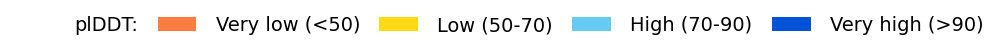

In [ ]:
#@title Display 3D structure {run: "auto"}
import ipywidgets as widgets
from IPython.display import display, HTML

#@markdown ---
rigid_body_idx = 0 #@param {type: "integer"}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")
color = "lDDT" #@param ["chain", "lDDT"]

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

rb_base_name = os.path.basename(rigid_body_pdb_file).split(".")[0]
#@markdown ---
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

headers_html = f"""
<div style="width: 1000px; display: flex; font-family: sans-serif; font-weight: bold; font-size: 14px; margin-bottom: 5px;">
  <div style="width: 50%; text-align: center; color: grey;">Source AlphaFold3 prediction</div>
  <div style="width: 50%; text-align: center; color: grey;">Extracted {rb_base_name}</div>
</div>
"""
display(HTML(headers_html))

show_pdb(prediction_cif_file, rigid_body_pdb_file, show_sidechains, show_mainchains, color).show()

if color == "lDDT":
  lddt_legend = plot_plddt_legend(dpi=87)
  lddt_legend.show()

pae_png = os.path.join(rb_dir, f"pae.png")
rb_pae_png = os.path.join(rb_dir, f"{rb_base_name}.png")

img1 = remove_transparency(pae_png)
img2 = remove_transparency(rb_pae_png)

widget1 = widgets.Image(value=img1, format='png', width=500)
widget2 = widgets.Image(value=img2, format='png', width=500)

side_by_side = widgets.HBox(
    [widget1, widget2],
    layout=widgets.Layout(background_color='white')
)
display(side_by_side)


## 1.g. Comparison with ground truth

In [ ]:
#@title Compute DockQ and TM-score

import warnings
warnings.filterwarnings('ignore')

rigid_body_idx = 0 #@param {type: "integer"}
chain_mapping_rigid_body = "AB:AB" #@param {type: "string", "placeholder": "Provide rigid body to ground truth chain map"}
get_score = "TM-score" #@param ["DockQ", "TM-score", ""]
column_width = 75 #@param {type:"slider", min:50, max:200, step:1}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")

num_chains = len(chain_mapping_rigid_body.split(":")[0])
if num_chains > 1:
    is_multimer = True
else:
    is_multimer = False

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

url = ground_truths[pred_name]["url"]
pdb_id = ground_truths[pred_name]["pdb_id"]
chain_mapping = ground_truths[pred_name]["chain_mapping"]
gt_dir = os.path.join(example_dir, "ground_truth")
os.makedirs(gt_dir, exist_ok=True)
outpath = os.path.join(gt_dir, f"{pdb_id}.pdb")

if os.path.exists(outpath):
    warnings.warn(f"Prediction files already exist in {prediction_dir}. Skipping...")
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)

if get_score == "DockQ":
    get_dockq_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, chain_mapping_model=chain_mapping, chain_mapping_rb=chain_mapping_rigid_body, col_width=column_width)

if get_score == "TM-score":
    get_tm_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, is_multimer=is_multimer, col_width=column_width)

******************************************************************************************************************************************************
TM-score comparison
******************************************************************************************************************************************************
Running commands:
1. !konda run "/content/af_pipeline_tutorial/USalign/USalign /content/af_pipeline_tutorial/example1/af_predictions/esterase_homodimer/esterase_2_1t656_87/fold_esterase_2_1t656_87_model_0.cif ./example1/ground_truth/7B5V.pdb"
2. !konda run "/content/af_pipeline_tutorial/USalign/USalign ./example1/rigid_bodies/esterase_homodimer_rigid_bodies/rigid_body_0.pdb ./example1/ground_truth/7B5V.pdb"

Model vs GT                                                                 | Rigid Body vs GT                                                           
                                                                            |                                   

## 1.h. Download results

In [ ]:
#@title Download results for example 1
zip_name = Path(example_dir).stem

download_button = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the rigid body pdb and assessment',
    icon='download'
)
def on_button_clicked_download(b):
    if os.path.exists(f"{zip_name}.zip") is False:
        shutil.make_archive(zip_name, 'zip', example_dir)
    files.download(f"{zip_name}.zip")

download_button.on_click(on_button_clicked_download)
display(download_button)

Button(button_style='success', description='Download', icon='download', style=ButtonStyle(), tooltip='Click to…

# **Example 2 - (Hands-on excercise)**
---

In [ ]:
#@title Hypoxia-inducible factor α (HIF-α)

#@markdown [PDB 101: Hypoxia-Inducible Factors](https://pdb101.rcsb.org/motm/240)
#@markdown - Oxygen-sensing protein that helps the cells survive under hypoxic conditions
#@markdown - In the presence of oxygen it is targeted for proteasomal degradation by the ubiquitination complex pVHL, the protein of the von Hippel Lindau (VHL) tumour suppressor gene and a component of an E3 ubiquitin ligase complex
#@markdown - UniProt IDs:
#@markdown   - ELOB: [Q15370](https://www.uniprot.org/uniprotkb/Q15370/entry)
#@markdown   - ELOC: [Q15369](https://www.uniprot.org/uniprotkb/Q15369/entry)
#@markdown   - VHL: [P40337](https://www.uniprot.org/uniprotkb/P40337/entry)
#@markdown   - HIF1A: [Q16665](https://www.uniprot.org/uniprotkb/Q16665/entry)

uniprot_ids = "Q15370,Q15369,P40337,Q16665" #@param {type:"string", placeholder:"Enter a comma separated list of UniProt IDs"}

fasta = query_uniprot_api_for_sequences(uniprot_ids=uniprot_ids.split(","))
fasta = only_uniprot_id_as_header(fasta_str=fasta)
print(f"\n{fasta}")

example_dir = "./example2"
prot_sequences_file = os.path.join(example_dir, "sequences", "protein_sequences.fasta")
os.makedirs(os.path.dirname(prot_sequences_file), exist_ok=True)

update_fasta_with_new_sequences(fasta=fasta, fasta_path=prot_sequences_file)
print(f"Updated fasta file: {prot_sequences_file}")

Successfully fetched sequences for given uniprot ids

>Q15370
MDVFLMIRRHKTTIFTDAKESSTVFELKRIVEGILKRPPDEQRLYKDDQLLDDGKTLGEC
GFTSQTARPQAPATVGLAFRADDTFEALCIEPFSSPPELPDVMKPQDSGSSANEQAVQ
>Q15369
MDGEEKTYGGCEGPDAMYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQFAENETNEV
NFREIPSHVLSKVCMYFTYKVRYTNSSTEIPEFPIAPEIALELLMAANFLDC
>P40337
MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPEELGAEEEMEAGRPR
PVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQPYPTLPPGTGRRIHSYRGHLWLFR
DAGTHDGLLVNQTELFVPSLNVDGQPIFANITLPVYTLKERCLQVVRSLVKPENYRRLDI
VRSLYEDLEDHPNVQKDLERLTQERIAHQRMGD
>Q16665
MEGAGGANDKKKISSERRKEKSRDAARSRRSKESEVFYELAHQLPLPHNVSSHLDKASVM
RLTISYLRVRKLLDAGDLDIEDDMKAQMNCFYLKALDGFVMVLTDDGDMIYISDNVNKYM
GLTQFELTGHSVFDFTHPCDHEEMREMLTHRNGLVKKGKEQNTQRSFFLRMKCTLTSRGR
TMNIKSATWKVLHCTGHIHVYDTNSNQPQCGYKKPPMTCLVLICEPIPHPSNIEIPLDSK
TFLSRHSLDMKFSYCDERITELMGYEPEELLGRSIYEYYHALDSDHLTKTHHDMFTKGQV
TTGQYRMLAKRGGYVWVETQATVIYNTKNSQPQCIVCVNYVVSGIIQHDLIFSLQQTECV
LKPVESSDMKMTQLFTKVESEDTSSLFDKLKKEPDALTLLAPAAGDTIISLDFGSNDTET
DDQQLEEVPLYNDVMLPSPNEKLQNINLAMSPLPTA

## 2.a. Creating input for AlphaFold-server

In [ ]:
config_yaml = """
# Fill up the missing fields

protein_uniprot_map:
  ELOB: "Q15370"
  ELOC: "Q15369"

af_input_jobs:
  - modelSeeds: [47, 33]
    entities:
    - name: ELOB
      type: "proteinChain"
    - name: ELOC
      type: "proteinChain"
"""

config_file = "config.yaml" #@param {type:"string"}
config_file = os.path.join(example_dir, config_file)

initialize_config_widget(config_yaml=config_yaml, config_file=config_file)

Textarea(value='\n# Fill up the missing fields\n\nprotein_uniprot_map:\n  ELOB: "Q15370"\n  ELOC: "Q15369"\n\n…

Button(button_style='success', description='Save', style=ButtonStyle())

## 2.b. Create a JSON file for AlphaFold-server

In [ ]:
output_dir = "af_server_json" #@param {type:"string"}
output_dir = os.path.join(example_dir, output_dir)

################################################################################

config_dict = read_yaml(config_file)
protein_sequences = read_fasta(prot_sequences_file)

af_input = AlphaFoldServer(
    config_dict=config_dict,
    protein_sequences=protein_sequences,
)

af_input.write_job_files(output_dir=output_dir)

################################################################################

json_files = list(Path(output_dir).glob("**/*.json"))
json_files = {f_path.stem: f_path for f_path in json_files}

if not json_files:
    print(f"No JSON files found in '{output_dir}'. Please upload some first!")
else:
    dropdown = widgets.Dropdown(
        options=list(json_files.keys()),
        description='JSON Files:',
        disabled=False,
    )

    button = widgets.Button(
        description='Download File',
        button_style='success',
        tooltip='Click to download the selected JSON file',
        icon='download'
    )

    def on_button_clicked(b):
        selected_file = dropdown.value
        full_path = json_files[selected_file]
        print(f"Downloading: {selected_file}...")
        files.download(full_path)

    button.on_click(on_button_clicked)

    display(widgets.VBox([dropdown, button]))

## 2.c. Obtain AlphaFold predictions

- Link to AlphaFold-server: https://alphafoldserver.com/

Only run one of the following cells. You can:
- Upload your own predictions **OR**
- Use pre-predicted AlphaFold-server results

In [ ]:
#@title Upload AlphaFold-server results
import shutil
from google.colab import files

overwrite = True #@param {type: "boolean"}

uploaded = files.upload()

prediction_dir = os.path.join(example_dir, "af_predictions")

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

for filename in uploaded.keys():
    os.makedirs(prediction_dir, exist_ok=True)
    source_path = filename
    destination_path = os.path.join(prediction_dir, filename)
    shutil.move(source_path, destination_path)
    print(f"Moved {filename} to {destination_path}")
    if os.path.exists(destination_path) and not os.path.exists(destination_path.replace(".zip", "")):
        !unzip {destination_path} -d {destination_path.replace(".zip", "")}

In [ ]:
#@title Fetch pre-predicted AlphaFold-server results

pred_name = "hifa_complex" #@param {type: "string"}
overwrite = True #@param {type: "boolean"}
url = pre_predicted_results[pred_name]
prediction_dir = os.path.join(example_dir, "af_predictions")
outpath = os.path.join(prediction_dir, f"{pred_name}.zip")
destination_path = os.path.join(prediction_dir, pred_name)

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

os.makedirs(prediction_dir, exist_ok=True)
if os.path.exists(outpath):
    if os.path.exists(destination_path) and os.path.isdir(destination_path):
        print(f"Prediction files already exist in {destination_path}. Skipping...")
    else:
        !unzip {outpath} -d {destination_path}
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)
    !unzip {outpath} -d {destination_path}

Downloading...
From: https://drive.google.com/uc?id=13FWDfOKceFca1XV9mZXRaBzLRahX61Xf
To: /content/af_pipeline_tutorial/example2/af_predictions/hifa_complex.zip
100%|██████████| 25.6M/25.6M [00:00<00:00, 224MB/s]


Archive:  ./example2/af_predictions/hifa_complex.zip
  inflating: ./example2/af_predictions/hifa_complex/terms_of_use.md  
  inflating: ./example2/af_predictions/hifa_complex/elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33/fold_elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33_job_request.json  
  inflating: ./example2/af_predictions/hifa_complex/elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33/msas/fold_elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33_unpaired_msa_chains_b.a3m  
  inflating: ./example2/af_predictions/hifa_complex/elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33/msas/fold_elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33_unpaired_msa_chains_c.a3m  
  inflating: ./example2/af_predictions/hifa_complex/elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33/msas/fold_elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33_paired_msa_chains_c.a3m  
  inflating: ./example2/af_predictions/hifa_complex/elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif

## 2.d. Rank predictions

- The best model is selected based on the following metrics in order of priority:
    1. Ranking Score
    2. Model Index (lower is better)
    3. ipTM
    4. pTM

In [ ]:
import warnings
warnings.filterwarnings('ignore')

best_predictions = "best_af_predictions.json" #@param {type: "string"}
best_pred_json_file = os.path.join(example_dir, best_predictions)

################################################################################

job_set_dirs = set(get_job_set_dirs(pred_dir=prediction_dir, pred_type="AF3"))

best_predictions = {}

for job_set_dir in list(set(job_set_dirs)):

    ranker = RankAF3JobSet(
        job_set_dir=job_set_dir,
        af_input_jobs=None,
        soft_match=True,
    )
    best_pred_info = ranker.extract_af3_best_pred_data()

    if len(best_pred_info) > 0:
        best_predictions.update(best_pred_info)

################################################################################

write_json(
    file_path=best_pred_json_file,
    data=best_predictions,
    indent=4,
)
print(f"\nBest predictions for {len(best_predictions)} job sets written to {best_pred_json_file}")


elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33

Best predictions for 1 job sets written to ./example2/best_af_predictions.json


## 2.e. Analysis of confident pairwise interactions

- Extracting confident residue-pair interactions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and a conttact threshold

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---

output_dir = "interaction_analysis" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)

overwrite = True #@param {type: "boolean"}

#@markdown ---

interaction_pae_cutoff = 5.0 # @param {type:"slider", min:0, max:10, step:1}

plddt_cutoff = 70  # @param {type:"slider", min:50, max:100, step:1}

contact_threshold = 10.0 # @param {type:"slider", min:5, max:12, step:1}

################################################################################

contact_map_files = perform_interaction_analysis(
    best_pred_json_file,
    output_dir,
    overwrite,
    interaction_pae_cutoff,
    plddt_cutoff,
    contact_threshold
)

Writing interacting patches to ./example2/interaction_analysis/hifa_complex/patches_elob_A:1-118_eloc_B:1-112.csv
Writing interacting patches to ./example2/interaction_analysis/hifa_complex/patches_elob_A:1-118_vhl_C:1-213.csv
Writing interacting patches to ./example2/interaction_analysis/hifa_complex/patches_eloc_B:1-112_hif1a_D:1-826.csv
Writing interacting patches to ./example2/interaction_analysis/hifa_complex/patches_eloc_B:1-112_vhl_C:1-213.csv
Writing interacting patches to ./example2/interaction_analysis/hifa_complex/patches_vhl_C:1-213_hif1a_D:1-826.csv


In [ ]:
#@title Display contact map

from IPython.display import HTML
from IPython.display import IFrame
import pandas as pd

dropdown = widgets.Dropdown(
    options=list(contact_map_files.keys()),
    description='Pairwise contact maps:',
    disabled=False,
)

button1 = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the contact map HTML file',
    icon='download'
)

button2a = widgets.Button(
    description='Display map',
    button_style='info',
    tooltip='Click to display the contact map',
    icon='eye'
)

button2b = widgets.Button(
    description='Display table',
    button_style='info',
    tooltip='Click to display the contact table',
    icon='eye'
)

button3 = widgets.Button(
    description="Clear",
    button_style='danger',
    tooltip='Click to clear the output',
    icon='trash'
)

output_area = widgets.Output()

def on_button_clicked1_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]
    print(f"Downloading: {selected_file}...")
    files.download(full_path)
    files.download(full_path.replace(".html", ".csv"))

def on_button_clicked2a_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]

    with output_area:
        output_area.clear_output()
        try:
            with open(full_path, 'r', encoding='utf-8') as f:
                html_str = f.read()

            if 'google.colab' in sys.modules:
                import google.colab.output
                safe_html_js = json.dumps(html_str)

                google.colab.output.eval_js(f"""
                    (function() {{
                        var oldFrame = document.getElementById('contact-map-container');
                        if (oldFrame) {{
                            oldFrame.remove();
                        }}

                        var iframe = document.createElement('iframe');
                        iframe.id = 'contact-map-container';
                        iframe.style.width = '100%';
                        iframe.style.height = '600px';
                        iframe.style.border = 'none';
                        document.body.appendChild(iframe);

                        var doc = iframe.contentWindow.document;
                        doc.open();
                        doc.write({safe_html_js});
                        doc.close();
                    }})();
                """)
            else:
                # Fallback for local JupyterLab / VS Code environments
                relative_path = os.path.relpath(full_path, start=os.getcwd())
                display(IFrame(src=relative_path, width="100%", height="600px"))

        except Exception as e:
            print(f"Error displaying file: {e}")

def on_button_clicked2b_interaction(b):
    selected_file = dropdown.value

    with output_area:
        output_area.clear_output()

        # Clean up the map iframe if it's open in Colab so they don't overlap
        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) { oldFrame.remove(); }
            """)

        try:
            # Assuming your CSV paths are in a dict named 'contact_map_files'
            # mapping the same keys as contact_map_files
            csv_path = contact_map_files[selected_file].replace(".html", ".csv")

            # Read and display the dataframe
            df = pd.read_csv(csv_path)
            display(df)

        except NameError:
            print("Error: 'contact_map_files' dictionary is not defined.")
        except Exception as e:
            print(f"Error displaying table: {e}")

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

button1.on_click(on_button_clicked1_interaction)
button2a.on_click(on_button_clicked2a_interaction)
button2b.on_click(on_button_clicked2b_interaction)
button3.on_click(on_button_clicked3_interaction)

button_row = widgets.HBox([button1, button2a, button2b, button3])
display(widgets.VBox([dropdown, button_row, output_area]))

## 2.f. Extracting confidently predicted regions (rigid bodies)

- Extracting confidently predicted regions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and community detection algorithm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---
output_dir = "rigid_bodies" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)
overwrite = True #@param {type: "boolean"}

#@markdown ---

pae_cutoff = 12.0 # @param {type:"slider", min:5, max:15, step:1}

plddt_cutoff = 70.0 # @param {type:"slider", min:50, max:100, step:1}

resolution = 0.5 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

pae_power = 1.0 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

library = "igraph" #@param ["networkx", "igraph"]

#@markdown ---

min_residues = 10 # @param {type:"slider", min:0, max:50, step:1}

min_proteins = 1 # @param {type:"slider", min:0, max:10, step:1}

################################################################################

rigid_body_files = extract_confident_regions(
    best_pred_json_file,
    output_dir,
    pae_cutoff,
    plddt_cutoff,
    resolution,
    pae_power,
    library,
    min_residues,
    min_proteins,
    overwrite
)

Extracting rigid bodies...
Rigid bodies for fold_elob_1_1t118_eloc_1_1t112_vhl_1_1t213_hif1a_1_1t826_33_model_0.cif saved in ./example2/rigid_bodies


In [ ]:
#@title Display 3D structure {run: "auto"}
import ipywidgets as widgets
from IPython.display import display, HTML

#@markdown ---
rigid_body_idx = 0 #@param {type: "integer"}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")
color = "lDDT" #@param ["chain", "lDDT"]

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

rb_base_name = os.path.basename(rigid_body_pdb_file).split(".")[0]
#@markdown ---
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

headers_html = f"""
<div style="width: 1000px; display: flex; font-family: sans-serif; font-weight: bold; font-size: 14px; margin-bottom: 5px;">
  <div style="width: 50%; text-align: center; color: grey;">Source AlphaFold3 prediction</div>
  <div style="width: 50%; text-align: center; color: grey;">Extracted {rb_base_name}</div>
</div>
"""
display(HTML(headers_html))

show_pdb(prediction_cif_file, rigid_body_pdb_file, show_sidechains, show_mainchains, color).show()

if color == "lDDT":
  lddt_legend = plot_plddt_legend(dpi=87)
  lddt_legend.show()

pae_png = os.path.join(rb_dir, f"pae.png")
rb_pae_png = os.path.join(rb_dir, f"{rb_base_name}.png")

img1 = remove_transparency(pae_png)
img2 = remove_transparency(rb_pae_png)

widget1 = widgets.Image(value=img1, format='png', width=500)
widget2 = widgets.Image(value=img2, format='png', width=500)

side_by_side = widgets.HBox(
    [widget1, widget2],
    layout=widgets.Layout(background_color='white')
)
display(side_by_side)


## 2.g. Comparison with ground truth

In [ ]:
#@title Compute DockQ and TM-score

import warnings
warnings.filterwarnings('ignore')

rigid_body_idx = 0 #@param {type: "integer"}
chain_mapping_rigid_body = "ABCD:ABCD" #@param {type: "string", "placeholder": "Provide rigid body to ground truth chain map"}
get_score = "DockQ" #@param ["DockQ", "TM-score", ""]
column_width = 100 #@param {type:"slider", min:50, max:200, step:1}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")

num_chains = len(chain_mapping_rigid_body.split(":")[0])
if num_chains > 1:
    is_multimer = True
else:
    is_multimer = False

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

url = ground_truths[pred_name]["url"]
pdb_id = ground_truths[pred_name]["pdb_id"]
chain_mapping = ground_truths[pred_name]["chain_mapping"]
gt_dir = os.path.join(example_dir, "ground_truth")
os.makedirs(gt_dir, exist_ok=True)
outpath = os.path.join(gt_dir, f"{pdb_id}.pdb")

if os.path.exists(outpath):
    warnings.warn(f"Prediction files already exist in {prediction_dir}. Skipping...")
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)

if get_score == "DockQ":
    get_dockq_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, chain_mapping_model=chain_mapping, chain_mapping_rb=chain_mapping_rigid_body, col_width=column_width)

if get_score == "TM-score":
    get_tm_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, is_multimer=is_multimer, col_width=column_width)

## 2.h. Download results

In [ ]:
#@title Download results for example 2
zip_name = Path(example_dir).stem

download_button = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the rigid body pdb and assessment',
    icon='download'
)
def on_button_clicked_download(b):
    if os.path.exists(f"{zip_name}.zip") is False:
        shutil.make_archive(zip_name, 'zip', example_dir)
    files.download(f"{zip_name}.zip")

download_button.on_click(on_button_clicked_download)
display(download_button)

# **Example 3 - (Hands-on excercise)**
---

In [ ]:
#@title Nucleosomes

#@markdown [PDB 101: Histones Across the Tree of Life](https://pdb101.rcsb.org/motm/314)
#@markdown - Genomic DNA in eukaryotes is wrapped around histones, forming structures known as nucleosomes
#@markdown - Four core histones (H2A, H2B, H3, and H4) form an octamer made up of two H2A-H2B and two H3-H4 heterodimers
#@markdown - UniProt IDs:
#@markdown   - H2A: [P06897](https://www.uniprot.org/uniprotkb/P06897/entry)
#@markdown   - H2B: [P02281](https://www.uniprot.org/uniprotkb/P02281/entry)
#@markdown   - H3C: [P02302](https://www.uniprot.org/uniprotkb/P02302/entry)
#@markdown   - H4: [P62799](https://www.uniprot.org/uniprotkb/P62799/entry)
# @markdown ---
uniprot_ids = "P06897,P02281,P02302,P62799" #@param {type:"string", placeholder:"Enter a list of comma separated UniProt IDs (e.g. P10709,Q99599)"}
# @markdown ---
dna_sequence = "ATCAATATCCACCTGCAGATTCTACCAAAAGTGTATTTGGAAACTGCTCCATCAAAAGGCATGTTCAGCTGAATTCAGCTGAACATGCCTTTTGATGGAGCAGTTTCCAAATACACTTTTGGTAGAATCTGCAGGTGGATATTGAT" #@param {type: "string"}
# @markdown ---
dna_fasta_content = f"""
>dna
{dna_sequence}
"""
print(dna_fasta_content)

example_dir = "./example3"
nuc_sequences_file = os.path.join(example_dir, "sequences", "nucleic_acid_sequences.fasta")
prot_sequences_file = os.path.join(example_dir, "sequences", "protein_sequences.fasta")

os.makedirs(os.path.dirname(nuc_sequences_file), exist_ok=True)
os.makedirs(os.path.dirname(prot_sequences_file), exist_ok=True)

with open(nuc_sequences_file, "w") as f:
    f.write(dna_fasta_content)
print(f"Updated fasta file: {nuc_sequences_file}\n")

fasta = query_uniprot_api_for_sequences(uniprot_ids=uniprot_ids.split(","))
fasta = only_uniprot_id_as_header(fasta_str=fasta)
print(fasta)

update_fasta_with_new_sequences(fasta=fasta, fasta_path=prot_sequences_file)
print(f"Updated fasta file: {prot_sequences_file}")

## 3.a. Creating input for AlphaFold-server

In [ ]:
config_yaml = """
# Fill up the missing fields

protein_uniprot_map:
  H2A: "P06897"

af_input_jobs:
  - modelSeeds: [47, 33]
    entities:
    - name: H2A
      type: "proteinChain"
      count: 2
    - name:
      type:
      count:
    - name:
      type:
      count:
    - name:
      type:
      count:
    - name: dna
      type: "dnaSequence"
      strand: "double"
"""

config_file = "config.yaml" #@param {type:"string"}
config_file = os.path.join(example_dir, config_file)

initialize_config_widget(config_yaml=config_yaml, config_file=config_file)

## 3.b. Create a JSON file for AlphaFold-server



In [ ]:
output_dir = "af_server_json" #@param {type:"string"}
output_dir = os.path.join(example_dir, output_dir)

################################################################################

config_dict = read_yaml(config_file)
protein_sequences = read_fasta(prot_sequences_file)
nucleic_acid_sequences = read_fasta(nuc_sequences_file)

af_input = AlphaFoldServer(
    config_dict=config_dict,
    protein_sequences=protein_sequences,
    nucleic_acid_sequences=nucleic_acid_sequences,
)

af_input.write_job_files(output_dir=output_dir)

################################################################################

json_files = list(Path(output_dir).glob("**/*.json"))
json_files = {f_path.stem: f_path for f_path in json_files}

if not json_files:
    print(f"No JSON files found in '{output_dir}'.")
else:
    dropdown = widgets.Dropdown(
        options=list(json_files.keys()),
        description='JSON Files:',
        disabled=False,
    )

    button = widgets.Button(
        description='Download File',
        button_style='success',
        tooltip='Click to download the selected JSON file',
        icon='download'
    )

    def on_button_clicked(b):
        selected_file = dropdown.value
        full_path = json_files[selected_file]
        print(f"Downloading: {selected_file}...")
        files.download(full_path)

    button.on_click(on_button_clicked)

    display(widgets.VBox([dropdown, button]))

## 3.c. Obtain AlphaFold predictions

- Link to AlphaFold-server: https://alphafoldserver.com/

Only run one of the following cells. You can:
- Upload your own predictions **OR**
- Use pre-predicted AlphaFold-server results

In [ ]:
#@title Upload AlphaFold-server results
import shutil
from google.colab import files

overwrite = True #@param {type: "boolean"}

uploaded = files.upload()

prediction_dir = os.path.join(example_dir, "af_predictions")

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

for filename in uploaded.keys():
    os.makedirs(prediction_dir, exist_ok=True)
    source_path = filename
    destination_path = os.path.join(prediction_dir, filename)
    shutil.move(source_path, destination_path)
    print(f"Moved {filename} to {destination_path}")
    if os.path.exists(destination_path) and not os.path.exists(destination_path.replace(".zip", "")):
        !unzip {destination_path} -d {destination_path.replace(".zip", "")}

In [ ]:
#@title Fetch pre-predicted AlphaFold-server results

pred_name = "nucleosome" #@param {type: "string"}
overwrite = True #@param {type: "boolean"}
url = pre_predicted_results[pred_name]
prediction_dir = os.path.join(example_dir, "af_predictions")
outpath = os.path.join(prediction_dir, f"{pred_name}.zip")
destination_path = os.path.join(prediction_dir, pred_name)

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

os.makedirs(prediction_dir, exist_ok=True)
if os.path.exists(outpath):
    if os.path.exists(destination_path) and os.path.isdir(destination_path):
        print(f"Prediction files already exist in {destination_path}. Skipping...")
    else:
        !unzip {outpath} -d {destination_path}
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)
    !unzip {outpath} -d {destination_path}

## 3.d. Rank predictions

- The best model is selected based on the following metrics in order of priority:
    1. Ranking Score
    2. Model Index (lower is better)
    3. ipTM
    4. pTM

In [ ]:
import warnings
warnings.filterwarnings('ignore')

best_predictions = "best_af_predictions.json" #@param {type: "string"}
best_pred_json_file = os.path.join(example_dir, best_predictions)

################################################################################

job_set_dirs = set(get_job_set_dirs(pred_dir=prediction_dir, pred_type="AF3"))

best_predictions = {}

for job_set_dir in list(set(job_set_dirs)):

    ranker = RankAF3JobSet(
        job_set_dir=job_set_dir,
        af_input_jobs=None,
        soft_match=True,
    )
    best_pred_info = ranker.extract_af3_best_pred_data()

    if len(best_pred_info) > 0:
        best_predictions.update(best_pred_info)

################################################################################

write_json(
    file_path=best_pred_json_file,
    data=best_predictions,
    indent=4,
)
print(f"\nBest predictions for {len(best_predictions)} job sets written to {best_pred_json_file}")


## 3.e. Analysis of confident pairwise interactions

- Extracting confident residue-pair interactions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and a conttact threshold

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---

output_dir = "interaction_analysis" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)

overwrite = True #@param {type: "boolean"}

#@markdown ---

interaction_pae_cutoff = 5.0 # @param {type:"slider", min:0, max:10, step:1}

plddt_cutoff = 70  # @param {type:"slider", min:50, max:100, step:1}

contact_threshold = 10.0 # @param {type:"slider", min:5, max:12, step:1}

################################################################################

contact_map_files = perform_interaction_analysis(
    best_pred_json_file,
    output_dir,
    overwrite,
    interaction_pae_cutoff,
    plddt_cutoff,
    contact_threshold
)

In [ ]:
#@title Display contact map

from IPython.display import HTML
from IPython.display import IFrame
import pandas as pd

dropdown = widgets.Dropdown(
    options=list(contact_map_files.keys()),
    description='Pairwise contact maps:',
    disabled=False,
)

button1 = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the contact map HTML file',
    icon='download'
)

button2a = widgets.Button(
    description='Display map',
    button_style='info',
    tooltip='Click to display the contact map',
    icon='eye'
)

button2b = widgets.Button(
    description='Display table',
    button_style='info',
    tooltip='Click to display the contact table',
    icon='eye'
)

button3 = widgets.Button(
    description="Clear",
    button_style='danger',
    tooltip='Click to clear the output',
    icon='trash'
)

output_area = widgets.Output()

def on_button_clicked1_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]
    print(f"Downloading: {selected_file}...")
    files.download(full_path)
    files.download(full_path.replace(".html", ".csv"))

def on_button_clicked2a_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]

    with output_area:
        output_area.clear_output()
        try:
            with open(full_path, 'r', encoding='utf-8') as f:
                html_str = f.read()

            if 'google.colab' in sys.modules:
                import google.colab.output
                safe_html_js = json.dumps(html_str)

                google.colab.output.eval_js(f"""
                    (function() {{
                        var oldFrame = document.getElementById('contact-map-container');
                        if (oldFrame) {{
                            oldFrame.remove();
                        }}

                        var iframe = document.createElement('iframe');
                        iframe.id = 'contact-map-container';
                        iframe.style.width = '100%';
                        iframe.style.height = '600px';
                        iframe.style.border = 'none';
                        document.body.appendChild(iframe);

                        var doc = iframe.contentWindow.document;
                        doc.open();
                        doc.write({safe_html_js});
                        doc.close();
                    }})();
                """)
            else:
                # Fallback for local JupyterLab / VS Code environments
                relative_path = os.path.relpath(full_path, start=os.getcwd())
                display(IFrame(src=relative_path, width="100%", height="600px"))

        except Exception as e:
            print(f"Error displaying file: {e}")

def on_button_clicked2b_interaction(b):
    selected_file = dropdown.value

    with output_area:
        output_area.clear_output()

        # Clean up the map iframe if it's open in Colab so they don't overlap
        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) { oldFrame.remove(); }
            """)

        try:
            # Assuming your CSV paths are in a dict named 'contact_map_files'
            # mapping the same keys as contact_map_files
            csv_path = contact_map_files[selected_file].replace(".html", ".csv")

            # Read and display the dataframe
            df = pd.read_csv(csv_path)
            display(df)

        except NameError:
            print("Error: 'contact_map_files' dictionary is not defined.")
        except Exception as e:
            print(f"Error displaying table: {e}")

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

button1.on_click(on_button_clicked1_interaction)
button2a.on_click(on_button_clicked2a_interaction)
button2b.on_click(on_button_clicked2b_interaction)
button3.on_click(on_button_clicked3_interaction)

button_row = widgets.HBox([button1, button2a, button2b, button3])
display(widgets.VBox([dropdown, button_row, output_area]))

## 3.f. Extracting confidently predicted regions (rigid bodies)

- Extracting confidently predicted regions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and community detection algorithm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---
output_dir = "rigid_bodies" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)
overwrite = True #@param {type: "boolean"}

#@markdown ---

pae_cutoff = 12.0 # @param {type:"slider", min:5, max:15, step:1}

plddt_cutoff = 70.0 # @param {type:"slider", min:50, max:100, step:1}

resolution = 0.5 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

pae_power = 1.0 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

library = "igraph" #@param ["networkx", "igraph"]

#@markdown ---

min_residues = 10 # @param {type:"slider", min:0, max:50, step:1}

min_proteins = 1 # @param {type:"slider", min:0, max:10, step:1}

################################################################################

rigid_body_files = extract_confident_regions(
    best_pred_json_file,
    output_dir,
    pae_cutoff,
    plddt_cutoff,
    resolution,
    pae_power,
    library,
    min_residues,
    min_proteins,
    overwrite
)

In [ ]:
#@title Display 3D structure {run: "auto"}
import ipywidgets as widgets
from IPython.display import display, HTML

#@markdown ---
rigid_body_idx = 0 #@param {type: "integer"}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")
color = "lDDT" #@param ["chain", "lDDT"]

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

rb_base_name = os.path.basename(rigid_body_pdb_file).split(".")[0]
#@markdown ---
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

headers_html = f"""
<div style="width: 1000px; display: flex; font-family: sans-serif; font-weight: bold; font-size: 14px; margin-bottom: 5px;">
  <div style="width: 50%; text-align: center; color: grey;">Source AlphaFold3 prediction</div>
  <div style="width: 50%; text-align: center; color: grey;">Extracted {rb_base_name}</div>
</div>
"""
display(HTML(headers_html))

show_pdb(prediction_cif_file, rigid_body_pdb_file, show_sidechains, show_mainchains, color).show()

if color == "lDDT":
  lddt_legend = plot_plddt_legend(dpi=87)
  lddt_legend.show()

pae_png = os.path.join(rb_dir, f"pae.png")
rb_pae_png = os.path.join(rb_dir, f"{rb_base_name}.png")

img1 = remove_transparency(pae_png)
img2 = remove_transparency(rb_pae_png)

widget1 = widgets.Image(value=img1, format='png', width=500)
widget2 = widgets.Image(value=img2, format='png', width=500)

side_by_side = widgets.HBox(
    [widget1, widget2],
    layout=widgets.Layout(background_color='white')
)
display(side_by_side)


## 3.g. Comparison with ground truth

In [ ]:
#@title Compute DockQ and TM-score

import warnings
warnings.filterwarnings('ignore')

rigid_body_idx = 0 #@param {type: "integer"}
chain_mapping_rigid_body = "ABCDEFGH:CGDHEAFB" #@param {type: "string", "placeholder": "Provide rigid body to ground truth chain map"}
get_score = "TM-score" #@param ["DockQ", "TM-score", ""]
column_width = 100 #@param {type:"slider", min:50, max:200, step:1}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")

num_chains = len(chain_mapping_rigid_body.split(":")[0])
if num_chains > 1:
    is_multimer = True
else:
    is_multimer = False

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

url = ground_truths[pred_name]["url"]
pdb_id = ground_truths[pred_name]["pdb_id"]
chain_mapping = ground_truths[pred_name]["chain_mapping"]
gt_dir = os.path.join(example_dir, "ground_truth")
os.makedirs(gt_dir, exist_ok=True)
outpath = os.path.join(gt_dir, f"{pdb_id}.pdb")

if os.path.exists(outpath):
    warnings.warn(f"Prediction files already exist in {prediction_dir}. Skipping...")
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)

if get_score == "DockQ":
    get_dockq_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, chain_mapping_model=chain_mapping, chain_mapping_rb=chain_mapping_rigid_body, col_width=column_width)

if get_score == "TM-score":
    get_tm_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, is_multimer=is_multimer, col_width=column_width)

## 3.h. Download results

In [ ]:
#@title Download results for example 3
zip_name = Path(example_dir).stem

download_button = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the rigid body pdb and assessment',
    icon='download'
)
def on_button_clicked_download(b):
    if os.path.exists(f"{zip_name}.zip") is False:
        shutil.make_archive(zip_name, 'zip', example_dir)
    files.download(f"{zip_name}.zip")

download_button.on_click(on_button_clicked_download)
display(download_button)

# **Example 4 - (Bonus excercise)**
---

In [ ]:
#@title Cadherin-catenin complex
#@markdown [PDB 101: Molecule of the Month: Cadherin](https://pdb101.rcsb.org/motm/99)
#@markdown - Cadherins are one of the many molecules that glue cells together
#@markdown - Cadherin tail is linked to the cytoskeleton by catenin proteins
#@markdown - UniProt IDs:
#@markdown   - Cdh1: [P09803](https://www.uniprot.org/uniprotkb/P09803/entry)
#@markdown   - Ctnnb1: [Q02248](https://www.uniprot.org/uniprotkb/Q02248/entry)

# @markdown ---
uniprot_ids = "P09803,Q02248" #@param {type:"string", placeholder:"Enter a comma separated list of UniProt IDs (e.g. O00629)"}

example_dir = "./example4"
prot_sequences_file = os.path.join(example_dir, "sequences", "protein_sequences.fasta")

os.makedirs(os.path.dirname(prot_sequences_file), exist_ok=True)

fasta = query_uniprot_api_for_sequences(uniprot_ids=uniprot_ids.split(","))
fasta = only_uniprot_id_as_header(fasta_str=fasta)
print(fasta)

update_fasta_with_new_sequences(fasta=fasta, fasta_path=prot_sequences_file)
print(f"Updated fasta file: {prot_sequences_file}")

## 4.a. Creating input for AlphaFold-server

In [ ]:
config_yaml = """
# Fill up the missing fields

protein_uniprot_map:
  Cdh1:
  Ctnnb1:

af_input_jobs:
  - modelSeeds: [47, 17]
    entities:
    - name:
      type:
    - name:
      type:
"""

config_file = "config.yaml" #@param {type:"string"}
config_file = os.path.join(example_dir, config_file)

initialize_config_widget(config_yaml=config_yaml, config_file=config_file)

## 4.b. Create a JSON file for AlphaFold-server

In [ ]:
output_dir = "af_server_json" #@param {type:"string"}
output_dir = os.path.join(example_dir, output_dir)

################################################################################

config_dict = read_yaml(config_file)
protein_sequences = read_fasta(prot_sequences_file)

af_input = AlphaFoldServer(
    config_dict=config_dict,
    protein_sequences=protein_sequences,
)

af_input.write_job_files(output_dir=output_dir)

################################################################################

json_files = list(Path(output_dir).glob("**/*.json"))
json_files = {f_path.stem: f_path for f_path in json_files}

if not json_files:
    print(f"No JSON files found in '{output_dir}'.")
else:
    dropdown = widgets.Dropdown(
        options=list(json_files.keys()),
        description='JSON Files:',
        disabled=False,
    )

    button = widgets.Button(
        description='Download File',
        button_style='success',
        tooltip='Click to download the selected JSON file',
        icon='download'
    )

    def on_button_clicked(b):
        selected_file = dropdown.value
        full_path = json_files[selected_file]
        print(f"Downloading: {selected_file}...")
        files.download(full_path)

    button.on_click(on_button_clicked)

    display(widgets.VBox([dropdown, button]))

## 4.c. Obtain AlphaFold predictions

- Link to AlphaFold-server: https://alphafoldserver.com/

Only run one of the following cells. You can:
- Upload your own predictions **OR**
- Use pre-predicted AlphaFold-server results

In [ ]:
#@title Upload AlphaFold-server results
import shutil
from google.colab import files

overwrite = True #@param {type: "boolean"}

uploaded = files.upload()

prediction_dir = os.path.join(example_dir, "af_predictions")

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

for filename in uploaded.keys():
    os.makedirs(prediction_dir, exist_ok=True)
    source_path = filename
    destination_path = os.path.join(prediction_dir, filename)
    shutil.move(source_path, destination_path)
    print(f"Moved {filename} to {destination_path}")
    if os.path.exists(destination_path) and not os.path.exists(destination_path.replace(".zip", "")):
        !unzip {destination_path} -d {destination_path.replace(".zip", "")}

In [ ]:
#@title Fetch pre-predicted AlphaFold-server results

pred_name = "cadherin_catenin_complex" #@param {type: "string"}
overwrite = True #@param {type: "boolean"}
url = pre_predicted_results[pred_name]
prediction_dir = os.path.join(example_dir, "af_predictions")
outpath = os.path.join(prediction_dir, f"{pred_name}.zip")
destination_path = os.path.join(prediction_dir, pred_name)

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

os.makedirs(prediction_dir, exist_ok=True)
if os.path.exists(outpath):
    if os.path.exists(destination_path) and os.path.isdir(destination_path):
        print(f"Prediction files already exist in {destination_path}. Skipping...")
    else:
        !unzip {outpath} -d {destination_path}
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)
    !unzip {outpath} -d {destination_path}

## 4.d. Rank predictions

- The best model is selected based on the following metrics in order of priority:
    1. Ranking Score
    2. Model Index (lower is better)
    3. ipTM
    4. pTM

In [ ]:
import warnings
warnings.filterwarnings('ignore')

best_predictions = "best_af_predictions.json" #@param {type: "string"}
best_pred_json_file = os.path.join(example_dir, best_predictions)

################################################################################

af_input_jobs = read_json(os.path.join(example_dir, "af_input_jobs.json"))
job_set_dirs = set(get_job_set_dirs(pred_dir=prediction_dir, pred_type="AF3"))

best_predictions = {}

for job_set_dir in list(set(job_set_dirs)):

    ranker = RankAF3JobSet(
        job_set_dir=job_set_dir,
        af_input_jobs=af_input_jobs.get("af_input_jobs"),
        soft_match=True,
    )
    best_pred_info = ranker.extract_af3_best_pred_data()

    if len(best_pred_info) > 0:
        best_predictions.update(best_pred_info)

################################################################################

write_json(
    file_path=best_pred_json_file,
    data=best_predictions,
    indent=4,
)
print(f"\nBest predictions for {len(best_predictions)} job sets written to {best_pred_json_file}")


## 4.e. Analysis of confident pairwise interactions

- Extracting confident residue-pair interactions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and a conttact threshold

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---

output_dir = "interaction_analysis" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)

overwrite = True #@param {type: "boolean"}

#@markdown ---

interaction_pae_cutoff = 5.0 # @param {type:"slider", min:0, max:10, step:1}

plddt_cutoff = 70  # @param {type:"slider", min:50, max:100, step:1}

contact_threshold = 10.0 # @param {type:"slider", min:5, max:12, step:1}

################################################################################

contact_map_files = perform_interaction_analysis(
    best_pred_json_file,
    output_dir,
    overwrite,
    interaction_pae_cutoff,
    plddt_cutoff,
    contact_threshold
)

In [ ]:
#@title Display contact map

from IPython.display import HTML
from IPython.display import IFrame
import pandas as pd

dropdown = widgets.Dropdown(
    options=list(contact_map_files.keys()),
    description='Pairwise contact maps:',
    disabled=False,
)

button1 = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the contact map HTML file',
    icon='download'
)

button2a = widgets.Button(
    description='Display map',
    button_style='info',
    tooltip='Click to display the contact map',
    icon='eye'
)

button2b = widgets.Button(
    description='Display table',
    button_style='info',
    tooltip='Click to display the contact table',
    icon='eye'
)

button3 = widgets.Button(
    description="Clear",
    button_style='danger',
    tooltip='Click to clear the output',
    icon='trash'
)

output_area = widgets.Output()

def on_button_clicked1_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]
    print(f"Downloading: {selected_file}...")
    files.download(full_path)
    files.download(full_path.replace(".html", ".csv"))

def on_button_clicked2a_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]

    with output_area:
        output_area.clear_output()
        try:
            with open(full_path, 'r', encoding='utf-8') as f:
                html_str = f.read()

            if 'google.colab' in sys.modules:
                import google.colab.output
                safe_html_js = json.dumps(html_str)

                google.colab.output.eval_js(f"""
                    (function() {{
                        var oldFrame = document.getElementById('contact-map-container');
                        if (oldFrame) {{
                            oldFrame.remove();
                        }}

                        var iframe = document.createElement('iframe');
                        iframe.id = 'contact-map-container';
                        iframe.style.width = '100%';
                        iframe.style.height = '600px';
                        iframe.style.border = 'none';
                        document.body.appendChild(iframe);

                        var doc = iframe.contentWindow.document;
                        doc.open();
                        doc.write({safe_html_js});
                        doc.close();
                    }})();
                """)
            else:
                # Fallback for local JupyterLab / VS Code environments
                relative_path = os.path.relpath(full_path, start=os.getcwd())
                display(IFrame(src=relative_path, width="100%", height="600px"))

        except Exception as e:
            print(f"Error displaying file: {e}")

def on_button_clicked2b_interaction(b):
    selected_file = dropdown.value

    with output_area:
        output_area.clear_output()

        # Clean up the map iframe if it's open in Colab so they don't overlap
        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) { oldFrame.remove(); }
            """)

        try:
            # Assuming your CSV paths are in a dict named 'contact_map_files'
            # mapping the same keys as contact_map_files
            csv_path = contact_map_files[selected_file].replace(".html", ".csv")

            # Read and display the dataframe
            df = pd.read_csv(csv_path)
            display(df)

        except NameError:
            print("Error: 'contact_map_files' dictionary is not defined.")
        except Exception as e:
            print(f"Error displaying table: {e}")

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

button1.on_click(on_button_clicked1_interaction)
button2a.on_click(on_button_clicked2a_interaction)
button2b.on_click(on_button_clicked2b_interaction)
button3.on_click(on_button_clicked3_interaction)

button_row = widgets.HBox([button1, button2a, button2b, button3])
display(widgets.VBox([dropdown, button_row, output_area]))

## 4.f. Extracting confidently predicted regions (rigid bodies)

- Extracting confidently predicted regions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and community detection algorithm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---
output_dir = "rigid_bodies" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)
overwrite = True #@param {type: "boolean"}

#@markdown ---

pae_cutoff = 12.0 # @param {type:"slider", min:5, max:15, step:1}

plddt_cutoff = 70.0 # @param {type:"slider", min:50, max:100, step:1}

resolution = 0.5 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

pae_power = 1.0 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

library = "igraph" #@param ["networkx", "igraph"]

#@markdown ---

min_residues = 10 # @param {type:"slider", min:0, max:50, step:1}

min_proteins = 1 # @param {type:"slider", min:0, max:10, step:1}

################################################################################

rigid_body_files = extract_confident_regions(
    best_pred_json_file,
    output_dir,
    pae_cutoff,
    plddt_cutoff,
    resolution,
    pae_power,
    library,
    min_residues,
    min_proteins,
    overwrite
)

In [ ]:
#@title Display 3D structure {run: "auto"}
import ipywidgets as widgets
from IPython.display import display, HTML

#@markdown ---
rigid_body_idx = 0 #@param {type: "integer"}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")
color = "chain" #@param ["chain", "lDDT"]

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

rb_base_name = os.path.basename(rigid_body_pdb_file).split(".")[0]
#@markdown ---
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

headers_html = f"""
<div style="width: 1000px; display: flex; font-family: sans-serif; font-weight: bold; font-size: 14px; margin-bottom: 5px;">
  <div style="width: 50%; text-align: center; color: grey;">Source AlphaFold3 prediction</div>
  <div style="width: 50%; text-align: center; color: grey;">Extracted {rb_base_name}</div>
</div>
"""
display(HTML(headers_html))

show_pdb(prediction_cif_file, rigid_body_pdb_file, show_sidechains, show_mainchains, color).show()

if color == "lDDT":
  lddt_legend = plot_plddt_legend(dpi=87)
  lddt_legend.show()

pae_png = os.path.join(rb_dir, f"pae.png")
rb_pae_png = os.path.join(rb_dir, f"{rb_base_name}.png")

img1 = remove_transparency(pae_png)
img2 = remove_transparency(rb_pae_png)

widget1 = widgets.Image(value=img1, format='png', width=500)
widget2 = widgets.Image(value=img2, format='png', width=500)

side_by_side = widgets.HBox(
    [widget1, widget2],
    layout=widgets.Layout(background_color='white')
)
display(side_by_side)


## 4.g. Comparison with ground truth

In [ ]:
#@title Compute DockQ and TM-score

import warnings
warnings.filterwarnings('ignore')

rigid_body_idx = 0 #@param {type: "integer"}
chain_mapping_rigid_body = "AB:BA" #@param {type: "string", "placeholder": "Provide rigid body to ground truth chain map"}
get_score = "TM-score" #@param ["DockQ", "TM-score", ""]
column_width = 100 #@param {type:"slider", min:50, max:200, step:1}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")

num_chains = len(chain_mapping_rigid_body.split(":")[0])
if num_chains > 1:
    is_multimer = True
else:
    is_multimer = False

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

url = ground_truths[pred_name]["url"]
pdb_id = ground_truths[pred_name]["pdb_id"]
chain_mapping = ground_truths[pred_name]["chain_mapping"]
gt_dir = os.path.join(example_dir, "ground_truth")
os.makedirs(gt_dir, exist_ok=True)
outpath = os.path.join(gt_dir, f"{pdb_id}.pdb")

if os.path.exists(outpath):
    warnings.warn(f"Prediction files already exist in {prediction_dir}. Skipping...")
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)

if get_score == "DockQ":
    get_dockq_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, chain_mapping_model=chain_mapping, chain_mapping_rb=chain_mapping_rigid_body, col_width=column_width)

if get_score == "TM-score":
    get_tm_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, is_multimer=is_multimer, col_width=column_width)

## 4.g. Download results

In [ ]:
#@title Download results for example 4
zip_name = Path(example_dir).stem

download_button = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the rigid body pdb and assessment',
    icon='download'
)
def on_button_clicked_download(b):
    if os.path.exists(f"{zip_name}.zip") is False:
        shutil.make_archive(zip_name, 'zip', example_dir)
    files.download(f"{zip_name}.zip")

download_button.on_click(on_button_clicked_download)
display(download_button)

# **Example - 5 (Bonus excercise)**
---

In [ ]:
#@title Nucleosome Assembly Protein 1 (NAP1) homodimer
#@markdown - A histone chaperone that plays a role in the nuclear import of H2A-H2B and nucleosome assembly
#@markdown - UniProt: [P55209](https://www.uniprot.org/uniprotkb/P55209/entry)

uniprot_ids = "P55209" #@param {type:"string", placeholder:"enter a UniProt ID"}

fasta = query_uniprot_api_for_sequences(uniprot_ids=uniprot_ids.split(","))
fasta = only_uniprot_id_as_header(fasta_str=fasta)
print(f"\n{fasta}")

example_dir = "./example5"
prot_sequences_file = os.path.join(example_dir, "sequences", "protein_sequences.fasta")
os.makedirs(os.path.dirname(prot_sequences_file), exist_ok=True)

update_fasta_with_new_sequences(fasta=fasta, fasta_path=prot_sequences_file)
print(f"Updated fasta file: {prot_sequences_file}")

## 5.a. Creating input for AlphaFold-server

In [ ]:
config_yaml = """
protein_uniprot_map:
  NAP1:

af_input_jobs:
  - modelSeeds: 2
    entities:
    - name:
      type:
      count:
"""

config_file = "config.yaml" #@param {type:"string"}
config_file = os.path.join(example_dir, config_file)

initialize_config_widget(config_yaml=config_yaml, config_file=config_file)

## 5.b. Create a JSON file for AlphaFold-server

In [ ]:
output_dir = "af_server_json" #@param {type:"string"}
output_dir = os.path.join(example_dir, output_dir)

################################################################################

config_dict = read_yaml(config_file)
protein_sequences = read_fasta(prot_sequences_file)

af_input = AlphaFoldServer(
    config_dict=config_dict,
    protein_sequences=protein_sequences,
)

af_input.write_job_files(output_dir=output_dir)

################################################################################

json_files = list(Path(output_dir).glob("**/*.json"))
json_files = {f_path.stem: f_path for f_path in json_files}

if not json_files:
    print(f"No JSON files found in '{output_dir}'. Please upload some first!")
else:
    dropdown = widgets.Dropdown(
        options=list(json_files.keys()),
        description='JSON Files:',
        disabled=False,
    )

    button = widgets.Button(
        description='Download File',
        button_style='success',
        tooltip='Click to download the selected JSON file',
        icon='download'
    )

    def on_button_clicked(b):
        selected_file = dropdown.value
        full_path = json_files[selected_file]
        print(f"Downloading: {selected_file}...")
        files.download(full_path)

    button.on_click(on_button_clicked)

    display(widgets.VBox([dropdown, button]))

## 5.c. Obtain AlphaFold predictions

- Link to AlphaFold-server: https://alphafoldserver.com/

Only run one of the following cells. You can:
- Upload your own predictions **OR**
- Use pre-predicted AlphaFold-server results

In [ ]:
#@title Upload AlphaFold-server results
import shutil
from google.colab import files

overwrite = True #@param {type: "boolean"}

uploaded = files.upload()

prediction_dir = os.path.join(example_dir, "af_predictions")

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

for filename in uploaded.keys():
    os.makedirs(prediction_dir, exist_ok=True)
    source_path = filename
    destination_path = os.path.join(prediction_dir, filename)
    shutil.move(source_path, destination_path)
    print(f"Moved {filename} to {destination_path}")
    if os.path.exists(destination_path) and not os.path.exists(destination_path.replace(".zip", "")):
        !unzip {destination_path} -d {destination_path.replace(".zip", "")}

In [ ]:
#@title Fetch pre-predicted AlphaFold-server results

pred_name = "nap1_homodimer" #@param {type: "string"}
overwrite = True #@param {type: "boolean"}
url = pre_predicted_results[pred_name]
prediction_dir = os.path.join(example_dir, "af_predictions")
outpath = os.path.join(prediction_dir, f"{pred_name}.zip")
destination_path = os.path.join(prediction_dir, pred_name)

if overwrite is True:
    shutil.rmtree(prediction_dir, ignore_errors=True)

os.makedirs(prediction_dir, exist_ok=True)
if os.path.exists(outpath):
    if os.path.exists(destination_path) and os.path.isdir(destination_path):
        print(f"Prediction files already exist in {destination_path}. Skipping...")
    else:
        !unzip {outpath} -d {destination_path}
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)
    !unzip {outpath} -d {destination_path}

## 5.d. Rank predictions

- The best model is selected based on the following metrics in order of priority:
    1. Ranking Score
    2. Model Index (lower is better)
    3. ipTM
    4. pTM

In [ ]:
import warnings
warnings.filterwarnings('ignore')

best_predictions = "best_af_predictions.json" #@param {type: "string"}
best_pred_json_file = os.path.join(example_dir, best_predictions)

################################################################################

job_set_dirs = set(get_job_set_dirs(pred_dir=prediction_dir, pred_type="AF3"))

best_predictions = {}

for job_set_dir in list(set(job_set_dirs)):

    ranker = RankAF3JobSet(
        job_set_dir=job_set_dir,
        af_input_jobs=None,
        soft_match=True,
    )
    best_pred_info = ranker.extract_af3_best_pred_data()

    if len(best_pred_info) > 0:
        best_predictions.update(best_pred_info)

################################################################################

write_json(
    file_path=best_pred_json_file,
    data=best_predictions,
    indent=4,
)
print(f"\nBest predictions for {len(best_predictions)} job sets written to {best_pred_json_file}")


## 5.e. Analysis of confident pairwise interactions

- Extracting confident residue-pair interactions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and a conttact threshold

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---

output_dir = "interaction_analysis" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)

overwrite = True #@param {type: "boolean"}

#@markdown ---

interaction_pae_cutoff = 5.0 # @param {type:"slider", min:0, max:10, step:1}

plddt_cutoff = 70  # @param {type:"slider", min:50, max:100, step:1}

contact_threshold = 10.0 # @param {type:"slider", min:5, max:12, step:1}

################################################################################

contact_map_files = perform_interaction_analysis(
    best_pred_json_file,
    output_dir,
    overwrite,
    interaction_pae_cutoff,
    plddt_cutoff,
    contact_threshold
)

In [ ]:
#@title Display contact map

from IPython.display import HTML
from IPython.display import IFrame
import pandas as pd

dropdown = widgets.Dropdown(
    options=list(contact_map_files.keys()),
    description='Pairwise contact maps:',
    disabled=False,
)

button1 = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the contact map HTML file',
    icon='download'
)

button2a = widgets.Button(
    description='Display map',
    button_style='info',
    tooltip='Click to display the contact map',
    icon='eye'
)

button2b = widgets.Button(
    description='Display table',
    button_style='info',
    tooltip='Click to display the contact table',
    icon='eye'
)

button3 = widgets.Button(
    description="Clear",
    button_style='danger',
    tooltip='Click to clear the output',
    icon='trash'
)

output_area = widgets.Output()

def on_button_clicked1_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]
    print(f"Downloading: {selected_file}...")
    files.download(full_path)
    files.download(full_path.replace(".html", ".csv"))

def on_button_clicked2a_interaction(b):
    selected_file = dropdown.value
    full_path = contact_map_files[selected_file]

    with output_area:
        output_area.clear_output()
        try:
            with open(full_path, 'r', encoding='utf-8') as f:
                html_str = f.read()

            if 'google.colab' in sys.modules:
                import google.colab.output
                safe_html_js = json.dumps(html_str)

                google.colab.output.eval_js(f"""
                    (function() {{
                        var oldFrame = document.getElementById('contact-map-container');
                        if (oldFrame) {{
                            oldFrame.remove();
                        }}

                        var iframe = document.createElement('iframe');
                        iframe.id = 'contact-map-container';
                        iframe.style.width = '100%';
                        iframe.style.height = '600px';
                        iframe.style.border = 'none';
                        document.body.appendChild(iframe);

                        var doc = iframe.contentWindow.document;
                        doc.open();
                        doc.write({safe_html_js});
                        doc.close();
                    }})();
                """)
            else:
                # Fallback for local JupyterLab / VS Code environments
                relative_path = os.path.relpath(full_path, start=os.getcwd())
                display(IFrame(src=relative_path, width="100%", height="600px"))

        except Exception as e:
            print(f"Error displaying file: {e}")

def on_button_clicked2b_interaction(b):
    selected_file = dropdown.value

    with output_area:
        output_area.clear_output()

        # Clean up the map iframe if it's open in Colab so they don't overlap
        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) { oldFrame.remove(); }
            """)

        try:
            # Assuming your CSV paths are in a dict named 'contact_map_files'
            # mapping the same keys as contact_map_files
            csv_path = contact_map_files[selected_file].replace(".html", ".csv")

            # Read and display the dataframe
            df = pd.read_csv(csv_path)
            display(df)

        except NameError:
            print("Error: 'contact_map_files' dictionary is not defined.")
        except Exception as e:
            print(f"Error displaying table: {e}")

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

def on_button_clicked3_interaction(b):
    with output_area:
        output_area.clear_output()

        if 'google.colab' in sys.modules:
            import google.colab.output
            google.colab.output.eval_js("""
                var oldFrame = document.getElementById('contact-map-container');
                if (oldFrame) {
                    oldFrame.remove();
                }
            """)

button1.on_click(on_button_clicked1_interaction)
button2a.on_click(on_button_clicked2a_interaction)
button2b.on_click(on_button_clicked2b_interaction)
button3.on_click(on_button_clicked3_interaction)

button_row = widgets.HBox([button1, button2a, button2b, button3])
display(widgets.VBox([dropdown, button_row, output_area]))

## 5.f. Extracting confidently predicted regions (rigid bodies)

- Extracting confidently predicted regions from AlphaFold predictions based on the assessment metrics provided by AlphaFold and community detection algorithm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#@markdown ---
output_dir = "rigid_bodies" #@param {type: "string"}
output_dir = os.path.join(example_dir, output_dir)
overwrite = True #@param {type: "boolean"}

#@markdown ---

pae_cutoff = 12.0 # @param {type:"slider", min:5, max:15, step:1}

plddt_cutoff = 70.0 # @param {type:"slider", min:50, max:100, step:1}

resolution = 0.5 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

pae_power = 1.0 # @param {type:"slider", min:0.2, max:2.0, step:0.2}

library = "igraph" #@param ["networkx", "igraph"]

#@markdown ---

min_residues = 10 # @param {type:"slider", min:0, max:50, step:1}

min_proteins = 1 # @param {type:"slider", min:0, max:10, step:1}

################################################################################

rigid_body_files = extract_confident_regions(
    best_pred_json_file,
    output_dir,
    pae_cutoff,
    plddt_cutoff,
    resolution,
    pae_power,
    library,
    min_residues,
    min_proteins,
    overwrite
)

In [ ]:
#@title Display 3D structure {run: "auto"}
import ipywidgets as widgets
from IPython.display import display, HTML

#@markdown ---
rigid_body_idx = 0 #@param {type: "integer"}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")
color = "chain" #@param ["chain", "lDDT"]

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

rb_base_name = os.path.basename(rigid_body_pdb_file).split(".")[0]
#@markdown ---
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

headers_html = f"""
<div style="width: 1000px; display: flex; font-family: sans-serif; font-weight: bold; font-size: 14px; margin-bottom: 5px;">
  <div style="width: 50%; text-align: center; color: grey;">Source AlphaFold3 prediction</div>
  <div style="width: 50%; text-align: center; color: grey;">Extracted {rb_base_name}</div>
</div>
"""
display(HTML(headers_html))

show_pdb(prediction_cif_file, rigid_body_pdb_file, show_sidechains, show_mainchains, color).show()

if color == "lDDT":
  lddt_legend = plot_plddt_legend(dpi=87)
  lddt_legend.show()

pae_png = os.path.join(rb_dir, f"pae.png")
rb_pae_png = os.path.join(rb_dir, f"{rb_base_name}.png")

img1 = remove_transparency(pae_png)
img2 = remove_transparency(rb_pae_png)

widget1 = widgets.Image(value=img1, format='png', width=500)
widget2 = widgets.Image(value=img2, format='png', width=500)

side_by_side = widgets.HBox(
    [widget1, widget2],
    layout=widgets.Layout(background_color='white')
)
display(side_by_side)


## 5.g. Comparison with ground truth

In [ ]:
#@title Compute DockQ and TM-score {run: "auto"}

import warnings
warnings.filterwarnings('ignore')

rigid_body_idx = 0 #@param {type: "integer"}
chain_mapping_rigid_body = "AB:BC" #@param {type: "string", "placeholder": "Provide rigid body to ground truth chain map"}
get_score = "DockQ" #@param ["DockQ", "TM-score", ""]
column_width = 200 #@param {type:"slider", min:50, max:200, step:1}
rb_dir = os.path.join(example_dir, "rigid_bodies", f"{pred_name}_rigid_bodies")

num_chains = len(chain_mapping_rigid_body.split(":")[0])
if num_chains > 1:
    is_multimer = True
else:
    is_multimer = False

best_preds = read_json(file_path=best_pred_json_file)

prediction_cif_file = best_preds[pred_name][BestPredictionFields.STRUCTURE_PATH]
rigid_body_pdb_file = os.path.join(rb_dir, f"rigid_body_{rigid_body_idx}.pdb")
assert os.path.exists(prediction_cif_file), f"Prediction file not found: {prediction_cif_file}"
assert os.path.exists(rigid_body_pdb_file), f"Rigid body file not found: {rigid_body_pdb_file}"

url = ground_truths[pred_name]["url"]
pdb_id = ground_truths[pred_name]["pdb_id"]
chain_mapping = ground_truths[pred_name]["chain_mapping"]
gt_dir = os.path.join(example_dir, "ground_truth")
os.makedirs(gt_dir, exist_ok=True)
outpath = os.path.join(gt_dir, f"{pdb_id}.pdb")

if os.path.exists(outpath):
    warnings.warn(f"Prediction files already exist in {prediction_dir}. Skipping...")
else:
    gdown.download(url, output=outpath, quiet=False, fuzzy=True)

if get_score == "DockQ":
    get_dockq_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, chain_mapping_model=chain_mapping, chain_mapping_rb=chain_mapping_rigid_body, col_width=column_width)

if get_score == "TM-score":
    get_tm_score(model_path=prediction_cif_file, rb_path=rigid_body_pdb_file, gt_path=outpath, is_multimer=is_multimer, col_width=column_width)

## 5.h. Download results

In [ ]:
#@title Download results for example 5
zip_name = Path(example_dir).stem

download_button = widgets.Button(
    description='Download',
    button_style='success',
    tooltip='Click to download the rigid body pdb and assessment',
    icon='download'
)
def on_button_clicked_download(b):
    if os.path.exists(f"{zip_name}.zip") is False:
        shutil.make_archive(zip_name, 'zip', example_dir)
    files.download(f"{zip_name}.zip")

download_button.on_click(on_button_clicked_download)
display(download_button)

# References

* Jumper, J. et al. Highly Accurate Protein Structure Prediction with Alphafold. Nature 596, 583–589 (2021).

* Abramson, J. et al. Accurate structure prediction of biomolecular interactions with AlphaFold 3. Nature 630, 493–500 (2024). (https://alphafoldserver.com/)

* AlphaFold Server. alphafoldserver.com. Available at: https://alphafoldserver.com/.

* Mirdita, M. et al. ColabFold: making protein folding accessible to all. Nature Methods 19, 679–682 (2022). (https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb)

* pae_to_domains: Graph-based community clustering approach to extract protein domains from a predicted aligned error matrix. Tristan Croll (https://github.com/tristanic/pae_to_domains).

<!-- ## Solutions

- example 2:
```yaml
protein_uniprot_map:
  "ELOB": "Q15370"
  "ELOC": "Q15369"
  "VHL": "P40337"
  "HIF1A": "Q16665"

af_input_jobs:
  - modelSeeds: [47, 33]
    entities:
    - name: ELOB
      type: "proteinChain"
    - name: ELOC
      type: "proteinChain"
    - name: VHL
      type: "proteinChain"
    - name: HIF1A
      type: "proteinChain"
```

- example3
```yaml
protein_uniprot_map:
  "H2A": "P06897"
  "H2B": "P02281"
  "H3C": "P02302"
  "H4": "P62799"

af_input_jobs:
  - modelSeeds: [47, 33]
    entities:
    - name: H2A
      type: "proteinChain"
      count: 2
    - name: H2B
      type: "proteinChain"
      count: 2
    - name: H3C
      type: "proteinChain"
      count: 2
    - name: H4
      type: "proteinChain"
      count: 2
    - name: dna
      type: "dnaSequence"
      strand: "double"
```

- example4
```yaml
protein_uniprot_map:
  Cdh1: "P09803"
  Ctnnb1: "Q02248"

af_input_jobs:
  - modelSeeds: [47, 17]
    entities:
    - name: "Cdh1"
      type: "proteinChain"
    - name: "Ctnnb1"
      type: "proteinChain"
```

- example5
```yaml
protein_uniprot_map:
  NAP1: "P55209"

af_input_jobs:
  - modelSeeds: 2
    entities:
    - name: NAP1
      type: "proteinChain"
      range: [1, 391]
      count: 2
``` -->